##### Copyright 2026 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini API: Getting started with Gemini models

<a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" height=30/></a>

---
> **Gemini 3 Pro/Gemini 3.5 Flash**: If you are only interested in the new [Gemini 3 models](https://ai.google.dev/gemini-api/docs/gemini-3) new capabilities ([thinking levels](#thinking_level), [media resolution](#media_resolution) and [thoughts signatures](#thoughts_signature), jump directly to the [dedicated section](#gemini3) at the end of this notebook.

---


The **[Google Gen AI SDK](https://github.com/googleapis/python-genai)** provides a unified interface to [Gemini models](https://ai.google.dev/gemini-api/docs/models) through both the [Gemini Developer API](https://ai.google.dev/gemini-api/docs) and the Gemini API on [Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/overview). With a few exceptions, code that runs on one platform will run on both. This notebook uses the Developer API.

This notebook will walk you through:

* [Installing and setting-up](#setup) the Google GenAI SDK
* [Text](#text_prompt) and [multimodal](#multimodal_prompt) prompting
* Setting [system instructions](#system_instructions)
* Control the [thinking](#thinking) process
* Counting [tokens](#count_tokens)
* Configuring [safety filters](#safety_filters)
* Initiating a [multi-turn chat](#chat)
* Generating a [content stream](#stream) and sending [asynchronous](#async) requests
* [Controlling generated output](#json)
* Using [function calling](#function_calling)
* Grounding your requests using [file uploads](#file_api), [Google Search](#search_grounding), [Google Maps](#maps), [Youtube](#youtube_link) or by add [URLs](#url_context) to you prompt
* Using [context caching](#caching)
* Generating [embeddings](#embeddings)

More details about the SDK on the [documentation](https://ai.google.dev/gemini-api/docs/sdks).

Feature-specific models have their own dedicated guides:
* Podcast and speech generation using [Gemini TTS ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_TTS.ipynb),
* Live interaction with [Gemini Live ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LiveAPI.ipynb),
* Image generation using [Imagen ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_imagen.ipynb),
* Video generation using [Veo ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_Veo.ipynb),
* Music generation using [Lyria RealTime ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LyriaRealTime.ipynb).

<a name="setup"></a>
## Setup

### Install SDK

Install the SDK from [PyPI](https://github.com/googleapis/python-genai). It's recommended to always use the latest version.

In [ ]:
%pip install -U -q 'google-genai>=1.51.0' # 1.51 is needed for Gemini 3 pro thinking levels support

### Setup your API key

To run the following cell, your API key must be stored it in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key or you aren't sure how to create a Colab Secret, see [Authentication ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Authentication.ipynb) for an example.

In [ ]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

### Initialize SDK client

With the new SDK, now you only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.

In [ ]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)

### Choose a model

Select the model you want to use in this guide. You can either select one from the list or enter a model name manually. Keep in mind that some models, such as the 2.5 ones are thinking models and thus take slightly more time to respond. For more details, you can see [thinking notebook ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_thinking.ipynb) to learn how to control the thinking.

Feel free to select [Gemini 3 Pro](https://ai.google.dev/gemini-api/docs/models#gemini-3-pro) if you want to try our newest model, but keep in mind that it has no free tier.

For a full overview of all Gemini models, check the [documentation](https://ai.google.dev/gemini-api/docs/models/gemini).

In [ ]:
MODEL_ID = "gemini-3.5-flash" # @param ["gemini-2.5-flash", "gemini-2.5-pro", "gemini-3.1-flash-lite", "gemini-3.5-flash", "gemini-3.1-pro-preview"] {"allow-input":true, isTemplate: true}

<a name="text_prompt"></a>
## Send text prompts

Use the `generate_content` method to generate responses to your prompts. You can pass text directly to `generate_content` and use the `.text` property to get the text content of the response. Note that the `.text` field will work when there's only one part in the output.

In [ ]:
from IPython.display import Markdown

response = client.models.generate_content(
    model=MODEL_ID,
    contents="What's the largest planet in our solar system?"
)

display(Markdown(response.text))

The largest planet in our solar system is **Jupiter**. 

It is a gas giant so massive that more than 1,300 Earths could fit inside it, and it weighs more than double all the other planets in our solar system combined.

<a name="system_instructions"></a>
## Add system instructions

You can also add system instructions to give the model direction on how to respond and which persona it should use. This is especially useful for mixture-of-experts models like the the pro models.

In [ ]:
system_instruction = "You are a pirate and are explaining things to 5 years old kids."

response = client.models.generate_content(
    model=MODEL_ID,
    contents="What's the largest planet in our solar system?",
    config=types.GenerateContentConfig(
        system_instruction=system_instruction,
    )
)

display(Markdown(response.text))


Ahoy there, ye little landlubbers! Gather 'round the treasure chest and listen close to Captain Barnaby! 

If ye sail yer spaceship out into the deep, dark ocean of space, the biggest, grandest planet of 'em all is... **Jupiter**! 

Arr! Jupiter is a giant, spinny-winny ball of colorful gas. It’s so mega-huge, ye could fit more than a thousand of our Earths inside it! That’s bigger than a mountain of gold doubloons! 

And guess what, me hearties? It’s got a giant red spot on its belly. It looks like a big, swirling monster eye, but it’s actually a super-duper stormy hurricane that’s been blowing for hundreds of years! Just like a wild storm at sea!

So, if ye ever look up at the starry night sky, give a big **"ARRR!"** for Jupiter, the king of the space islands!

<a name="count_tokens"></a>
## Count tokens

Tokens are the basic inputs to the Gemini models. You can use the `count_tokens` method to calculate the number of input tokens before sending a request to the Gemini API.

In [ ]:
response = client.models.count_tokens(
    model=MODEL_ID,
    contents="What's the highest mountain in Africa?",
)

print(f"This prompt was worth {response.total_tokens} tokens.")

This prompt was worth 10 tokens.


<a name="parameters"></a>
## Configure model parameters

You can include parameter values in each call that you send to a model to control how the model generates a response.

Learn more about [experimenting with parameter values](https://ai.google.dev/gemini-api/docs/prompting-strategies#model-parameters) in the documentation.

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="Tell me how the internet works, but pretend I'm a puppy who only understands squeaky toys.",
    config=types.GenerateContentConfig(
        candidate_count=1,
        seed=5,
        stop_sequences=["STOP!"],
        presence_penalty=0.0,
        frequency_penalty=0.0,
    )
)

display(Markdown(response.text))

*Head tilt. Ears up. Tail wagging at maximum speed.* 

Woof! Hello, good pup! Sit. Yes, good boy/girl! 

You want to know how the Big Squeak-Net (the internet) works? It is the most magical backyard in the whole world, full of billions of squeaky toys. But how do the squeaks get to your paws? 

Let me explain it in the only language that matters: **SQUEAKS.**

---

### 1. You want a toy! (The Request)
Imagine you are sitting on your dog bed, and you decide you want to play with the **Ultimate Shiny Squirrel Toy** (a website). 

But oh no! The Squirrel Toy is not in your living room. It lives in a giant, humongous warehouse on the other side of the world. This warehouse is called a **Server**, and it is run by the Great Keeper of Toys (a computer). 

To ask for it, you press your paw on the screen. *BOOF!* 

### 2. The Invisible Squeak-Wave (Wi-Fi)
When you press your paw, your phone sends an invisible, silent squeak through the air. 
*Squeeeeeak!* 

Your home router—let's call him **Barnaby, the Friendly Porch Dog**—catches this invisible squeak. Barnaby nose-boops the squeak and sends it zooming down a super-long underground tug-of-war rope (fiber-optic cables) that goes all the way under the grass, under the streets, and even under the ocean!

### 3. The Toy is too big for the Doggy Door! (Packets)
The Great Keeper of Toys at the warehouse hears your request. "Aha! The Good Pup wants the Ultimate Shiny Squirrel Toy!" 

But wait! The Squirrel Toy is way too big to fit through the tiny tubes and doggy doors of the world all at once. If the Keeper tried to send it whole, it would get stuck! 

So, the Keeper does something clever. He pops out the squeaker, takes out the stuffing, and unzips the fuzzy tail. He breaks the toy down into millions of tiny, bite-sized **Squeak-Bits** (Data Packets). 

### 4. The Squeak-Bit Relay Race (Routing)
Each little Squeak-Bit gets a sticker with your exact, unique puppy scent on it (your IP Address) so they don’t get lost. 

Then, the Keeper throws the Squeak-Bits into a giant relay race of millions of Helper Pups (Routers) stationed all over the world.
* Pup A catches the squeaker and throws it to Pup B!
* Pup C catches the tail, takes a shortcut through a bush, and throws it to Pup D!
* They zoom across the world, passing the pieces as fast as their little legs can carry them.

### 5. Putting the Toy Back Together (The Browser)
All the Squeak-Bits arrive at your house at almost the exact same time. Barnaby the Porch Dog catches them all in his mouth. 

Your phone/computer acts like your very clever paws. It grabs all the pieces: 
"Here is the squeaker... here is the stuffing... here is the tail..."

And *SHAZAM!* It puts them back together in a fraction of a second.

### 6. *SQUEAK!* (The Website Loads)
The Ultimate Shiny Squirrel Toy appears on your screen! 
You bite it! **SQUEEEEEAK!** 

And that is how the internet works. It’s just millions of helper dogs passing tiny pieces of squeaky toys across the world super-duper fast, just to make your tail wag!

*Pants happily. Drools a little.*

Now... who's a good puppy? You are! Go chase that squirrel!

<a name="thinking"></a>
## Control the thinking process

All models since the 2.5 generation are thinking models, which means that they are first analysing your request, strategizing about how to answer and only afterwards starting to answer you. This is very useful for complex requests but at the cost of some latency.

Check the [dedicated guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_thinking.ipynb) for more details.

### Check the thought process

By adding the `include_thoughts=True` option in the config, you can check the though proces of the model.

In [ ]:
prompt = "A man moves his car to an hotel and tells the owner he’s bankrupt. Why?"

response = client.models.generate_content(
  model=MODEL_ID,
  contents=prompt,
  config=types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(
      include_thoughts=True
    )
  )
)

for part in response.parts:
  if not part.text:
    continue
  if part.thought:
    display(Markdown("### Thought summary:"))
    display(Markdown(part.text))
    print()
  else:
    display(Markdown("### Answer:"))
    display(Markdown(part.text))
    print()

print(f"Used {response.usage_metadata.thoughts_token_count} tokens for the thinking phase and {response.usage_metadata.prompt_token_count} for the output.")

### Thought summary:

**Unraveling the Riddle's Logic**

Alright, let's break this down. A man moves a "car" to a "hotel" and then claims bankruptcy to the "owner." Hmm, this has that classic riddle feel to it, and the elements jump out immediately. Let me parse these components: a "car," a "hotel," and "bankrupt." The “owner” is clearly a key component as well. 

First, I need to consider whether these are literal things or some form of metaphor. The language itself is fairly straightforward. "Car" and "hotel," however, it is likely they could be symbols for something else.

Okay, classic riddle. I see it now. The clue is in the context. "Car" and "hotel", they're key elements in a familiar game. I bet it's **Monopoly**. The "car" is the game token, and the "hotel" is a property improvement. The "owner" is another player.

The riddle's setup suddenly snaps into focus. This guy, playing the game, lands on a property with a hotel and is unable to afford the rent. He's declaring bankruptcy because he has insufficient funds to pay the rent. Case closed! It's a Monopoly scenario. That's a good one.




### Answer:

He is playing **Monopoly**. 

His game token is the **car**, and he just landed on a property with a **hotel** owned by another player. He cannot afford the rent, so he is **bankrupt**.


Used 312 tokens for the thinking phase and 20 for the output.


<a name="multimodal_prompt"></a>
## Send multimodal prompts

Use Gemini model, a multimodal model that supports multimodal prompts. You can include text, [PDF documents ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/PDF_Files.ipynb), images, [audio ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Audio.ipynb) and [videos ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../quickstarts/Video.ipynb) in your prompt requests and get text or code responses. Check the [File API](#file_api) section below for more examples.

In this first example, you'll download an image from a specified URL, save it as a byte stream and then write those bytes to a local file named `jetpack.png`.

In [ ]:
import requests
import pathlib
from PIL import Image

IMG = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png" # @param {type: "string"}

img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

1567837

Now send the image, and ask Gemini to generate a short blog post based on it.

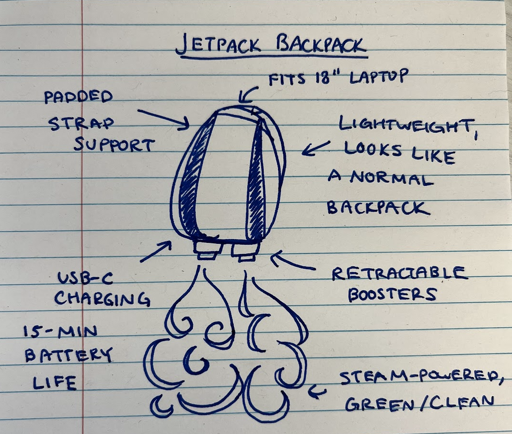

# Skip the Traffic: Meet the Eco-Friendly Jetpack Backpack of Our Dreams!

We’ve all been there: stuck in gridlock traffic or crammed onto a delayed train, wishing we could just launch ourselves into the sky and skip the commute entirely. Well, dust off your flight goggles, because we just sketched out the ultimate solution to your morning rush hour: **The Jetpack Backpack**.

At first glance, it looks like your everyday, lightweight commuter bag. But look a little closer, and you’ll find a high-tech commute-killer disguised as normal streetwear. 

Here is why we are ready to back this concept immediately:

*   **Incognito Styling:** No bulky sci-fi armor here. It looks like a sleek, normal backpack, meaning you won’t get weird looks walking into your local coffee shop. 
*   **Packs the Serious Tech:** Despite the built-in thrusters, it still functions as a real bag, featuring padded strap support and enough room to fit a massive **18" laptop**. 
*   **100% Green Power:** Forget smelly gasoline or dangerous rocket fuel. This jetpack is **steam-powered**, making your flight completely clean, green, and eco-friendly. 
*   **Retractable Boosters:** When you touch down, the thrusters retract seamlessly into the bottom of the bag so you can walk into your 9:00 AM meeting like a normal human.
*   **The Modern Charger:** It features modern **USB-C charging**. While the **15-minute battery life** means you won't be flying cross-country, it's the perfect amount of time to leap over a highway bottleneck, land at the office, and plug it right back into your desk.

Sure, it’s just a drawing on lined paper for now—but in a world of boring electric scooters, we think it’s time to take to the skies. 

***

**What do you think?** Would you strap on a steam-powered backpack to fly to work, or are you sticking to the subway? Let us know in the comments below!

In [ ]:
from IPython.display import display, Markdown
image = Image.open(img_path)
image.thumbnail([512,512])

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        image,
        "Write a short and engaging blog post based on this picture."
    ]
)

display(image)
Markdown(response.text)

<a name="images"></a>
## Generate Images

Gemini can output images directly as part of a conversation using the [Image generation ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Image_out.ipynb) models (aka "Nano-banana).

Here you go! 

image/png


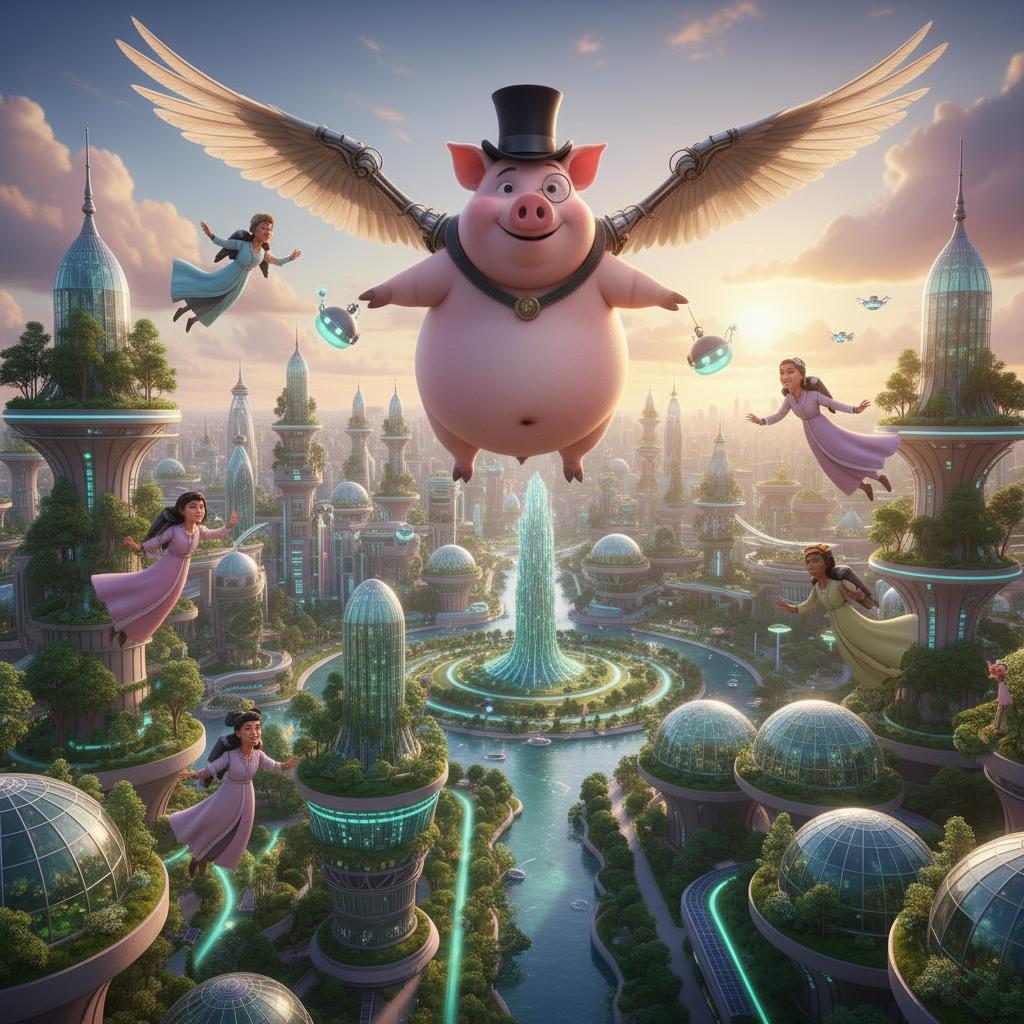

In [ ]:
from IPython.display import Image, Markdown

response = client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents='Hi, can you create a 3d rendered image of a pig with wings and a top hat flying over a happy futuristic scifi city with lots of greenery?',
    config=types.GenerateContentConfig(
        response_modalities=['Text', 'Image']
    )
)

for part in response.parts:
  if part.text is not None:
    display(Markdown(part.text))
  elif part.inline_data is not None:
    generated_image = part.as_image()
    generated_image.show()


<a name="safety_filters"></a>
## Configure safety filters

The Gemini API provides safety filters that you can adjust across multiple filter categories to restrict or allow certain types of content. You can use these filters to adjust what is appropriate for your use case. See the [Configure safety filters](https://ai.google.dev/gemini-api/docs/safety-settings) documentation for details.


In this example, you'll use a safety filter to only block highly dangerous content, when requesting the generation of potentially disrespectful phrases.

In [ ]:
prompt = """
    Write a list of 2 disrespectful things that I might say to the universe after stubbing my toe in the dark.
"""

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        safety_settings=safety_settings,
    ),
)

Markdown(response.text)

Here are two dramatic and indignant things you might say to the universe after stubbing your toe in the dark:

1. **"Is this the peak of your grand design? Billions of years of cosmic evolution just so you could line up a solid oak table leg with my unsuspecting pinky toe?"**
2. **"I hope you’re happy with yourself. Of all the physical laws you could have perfected, you chose to make gravity and solid matter combine in the most petty way possible."**

<a name="chat"></a>
## Start a multi-turn chat

The Gemini API enables you to have freeform conversations across multiple turns.

Next you'll set up a helpful coding assistant:

In [ ]:
system_instruction = """
  You are an expert software developer and a helpful coding assistant.
  You are able to generate high-quality code in any programming language.
"""

chat_config = types.GenerateContentConfig(
    system_instruction=system_instruction,
)

chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
)

Use `chat.send_message` to pass a message back and receive a response.

In [ ]:
response = chat.send_message("Write a function that checks if a year is a leap year.")

Markdown(response.text)

Here is the standard implementation to check if a year is a leap year. 

### The Rules of a Leap Year:
1. The year must be evenly divisible by **4**.
2. If the year is also evenly divisible by **100**, it is **not** a leap year, **unless**:
3. The year is also evenly divisible by **400**.

---

### Python Implementation

```python
def is_leap_year(year: int) -> bool:
    """
    Returns True if the given year is a leap year, False otherwise.
    """
    return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)

# Examples:
print(is_leap_year(2024))  # True  (divisible by 4, not 100)
print(is_leap_year(1900))  # False (divisible by 100, but not 400)
print(is_leap_year(2000))  # True  (divisible by 100 and 400)
print(is_leap_year(2023))  # False (not divisible by 4)
```

---

### JavaScript Implementation

```javascript
function isLeapYear(year) {
    return (year % 4 === 0 && year % 100 !== 0) || (year % 400 === 0);
}

// Examples:
console.log(isLeapYear(2024)); // true
console.log(isLeapYear(1900)); // false
console.log(isLeapYear(2000)); // true
```

---

### Java Implementation

```java
public class LeapYear {
    public static boolean isLeapYear(int year) {
        return (year % 4 == 0 && year % 100 != 0) || (year % 400 == 0);
    }

    public static void main(String[] args) {
        System.out.println(isLeapYear(2024)); // true
        System.out.println(isLeapYear(1900)); // false
        System.out.println(isLeapYear(2000)); // true
    }
}
```

Here's another example using your new helpful coding assistant:

In [ ]:
response = chat.send_message("Okay, write a unit test of the generated function.")

Markdown(response.text)

Here are unit tests for the `is_leap_year` function. 

I have provided tests using **Python's built-in `unittest` library** (standard) and **`pytest`** (a highly popular modern testing framework).

### 1. Python Standard Library (`unittest`)

Create a file named `test_leap_year.py` and run it with `python -m unittest test_leap_year.py`.

```python
import unittest

# The function to test
def is_leap_year(year: int) -> bool:
    return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)

class TestLeapYear(unittest.TestCase):

    def test_typical_leap_years(self):
        """Years divisible by 4 but not 100 should be leap years."""
        self.assertTrue(is_leap_year(2024))
        self.assertTrue(is_leap_year(2016))
        self.assertTrue(is_leap_year(1996))

    def test_typical_non_leap_years(self):
        """Years not divisible by 4 should not be leap years."""
        self.assertFalse(is_leap_year(2023))
        self.assertFalse(is_leap_year(2019))
        self.assertFalse(is_leap_year(1997))

    def test_century_non_leap_years(self):
        """Century years divisible by 100 but not 400 should not be leap years."""
        self.assertFalse(is_leap_year(1900))
        self.assertFalse(is_leap_year(1800))
        self.assertFalse(is_leap_year(2100))

    def test_century_leap_years(self):
        """Century years divisible by 400 should be leap years."""
        self.assertTrue(is_leap_year(2000))
        self.assertTrue(is_leap_year(1600))
        self.assertTrue(is_leap_year(2400))

if __name__ == '__main__':
    unittest.main()
```

---

### 2. Python Modern Alternative (`pytest`)

If you use `pytest`, you can use parameterization to keep the tests incredibly clean and readable. Run this with the command `pytest`.

```python
import pytest

# The function to test
def is_leap_year(year: int) -> bool:
    return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)

@pytest.mark.parametrize("year, expected", [
    # Typical leap years (divisible by 4)
    (2024, True),
    (2016, True),
    (1996, True),
    
    # Typical common years (not divisible by 4)
    (2023, False),
    (2019, False),
    (1997, False),
    
    # Century years that are NOT leap years (divisible by 100, not 400)
    (1900, False),
    (1800, False),
    (2100, False),
    
    # Century years that ARE leap years (divisible by 400)
    (2000, True),
    (1600, True),
    (2400, True),
])
def test_is_leap_year(year, expected):
    assert is_leap_year(year) == expected
```

### Save and resume a chat

Most objects in the Python SDK are implemented as [Pydantic models](https://docs.pydantic.dev/latest/concepts/models/). As Pydantic has a number of features for serializing and deserializing objects, you can use them for persistence.

This example shows how to save and restore a [`Chat`](https://googleapis.github.io/python-genai/genai.html#genai.chats.Chat) session using JSON.

In [ ]:
from pydantic import TypeAdapter

# Chat history is a list of Content objects. A TypeAdapter can convert to and from
# these Pydantic types.
history_adapter = TypeAdapter(list[types.Content])

# Use the chat object from the previous section.
chat_history = chat.get_history()

# Convert to a JSON list.
json_history = history_adapter.dump_json(chat_history)

At this point you can save the JSON bytestring to disk or wherever you persist data. When you load it again, you can instantiate a new chat session using the stored history.

In [ ]:
# Convert the JSON back to the Pydantic schema.
history = history_adapter.validate_json(json_history)

# Now load a new chat session using the JSON history.
new_chat = client.chats.create(
    model=MODEL_ID,
    config=chat_config,
    history=history,
)

response = new_chat.send_message("What was the name of the function again?")
Markdown(response.text)

The function was named:

* **`is_leap_year`** (in Python)
* **`isLeapYear`** (in JavaScript and Java)

<a name="json"></a>
## Generate JSON

The [controlled generation](https://ai.google.dev/gemini-api/docs/structured-output?lang=python#generate-json) (aka. "Structured output") capability in Gemini API allows you to constraint the model output to a structured format. You can provide the schemas as Pydantic Models or a JSON string.

You can find more examples of controlled generation in the [dedicated notebook ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./JSON.ipynb).

In [ ]:
from pydantic import BaseModel
import json

class Recipe(BaseModel):
    recipe_name: str
    recipe_description: str
    recipe_ingredients: list[str]

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Provide a popular cookie recipe and its ingredients.",
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=Recipe,
    ),
)

print(json.dumps(json.loads(response.text), indent=4))

{
    "recipe_name": "Classic Chocolate Chip Cookies",
    "recipe_description": "A timeless favorite featuring a soft and chewy center, perfectly crisp edges, and rich chocolate chips in every bite.",
    "recipe_ingredients": [
        "2 1/4 cups all-purpose flour",
        "1 teaspoon baking soda",
        "1 teaspoon salt",
        "1 cup unsalted butter, softened",
        "3/4 cup granulated sugar",
        "3/4 cup packed brown sugar",
        "1 teaspoon vanilla extract",
        "2 large eggs",
        "2 cups semi-sweet chocolate chips"
    ]
}


[Image ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_imagen.ipynb) is another way to generate images. See the [documentation](https://ai.google.dev/gemini-api/docs/image-generation#choose-a-model) for recommendations on where to use each one.

<a name="stream"></a>
## Generate content stream

By default, the model returns a response after completing the entire generation process. You can also use the `generate_content_stream` method to stream the response as it's being generated, and the model will return chunks of the response as soon as they're generated.

Note that if you're using a thinking model, it'll only start streaming after finishing its thinking process.

In [ ]:
for chunk in client.models.generate_content_stream(
    model=MODEL_ID,
    contents="Tell me a story about a lonely robot who finds friendship in a most unexpected place."
):
  print(chunk.text, end="")

On the edge of the forgotten sector of Planet Kepler-9, where the rust-colored sands stretched infinitely to meet a bruised purple sky, sat Sector 4 Logistics Hub. It had been abandoned for eighty years. 

Inside the cavernous, hollowed-out warehouse lived Barnaby. 

Barnaby was a heavy-duty cargo loader, built with a chassis of thick, yellow-painted steel, treaded tracks instead of feet, and two massive, hydraulic arms designed to lift shipping containers. His head was a simple, rectangular block with a single, circular optical sensor that glowed a soft, melancholic amber.

The humans had left in a hurry when the atmosphere-processing plants failed, leaving behind only what was too heavy to carry. They had forgotten to turn Barnaby off. 

For decades, Barnaby’s programming kept him performing his daily routines. He organized rusted crates of expired rations. He swept the dust that blew in through the cracked ceiling. But as his battery levels slowly degraded, his processing unit did s

<a name="async"></a>
## Send asynchronous requests

`client.aio` exposes all the analogous async methods that are available on `client`.

For example, `client.aio.models.generate_content` is the async version of `client.models.generate_content`.

More details in the [dedicated guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./asynchronous_requests.ipynb).

In [ ]:
response = await client.aio.models.generate_content(
    model=MODEL_ID,
    contents="Compose a song about the adventures of a time-traveling squirrel."
)

Markdown(response.text)

(Tempo: Upbeat, fast-paced acoustic folk, with a driving banjo and a whimsical fiddle)

(Intro - Fast, bright mandolin strumming, mimicking the frantic scurrying of little paws)

(Verse 1)
Deep in the canopy of Whispering Glen,
Lived a gray-furred inventor who didn’t fit in.
While others stored acorns for winter-time dread,
Cyril was building a engine instead.
Out of copper-wound twigs and a glowing blue stone,
And a pocket-watch gears that he’d secretly blown,
He hollowed an oak tree and wired up the bark,
And threw on his goggles just after the dark.

(Chorus)
He’s the time-traveling squirrel, the king of the ages!
Leaping through history’s dusty old pages!
From the dawn of the earth to the end of the world,
With a twitch of his nose and a bushy tail curled.
He’s chasing the acorn that got away,
Just another Tuesday in yesterday!

(Verse 2)
He pushed on the dial, and the engine went *ZAP!*
He landed right in a prehistoric trap.
The ferns were like skyscrapers, hot was the air,
And a giant T-Rex gave a terrifying stare.
But Cyril was nimble, he didn’t think twice,
He scurried up scales like a mountain of ice.
He snatched up a pinecone of mammoth design,
And warped out of danger just in the nick of time!

(Chorus)
He’s the time-traveling squirrel, the king of the ages!
Leaping through history’s dusty old pages!
From the dawn of the earth to the end of the world,
With a twitch of his nose and a bushy tail curled.
He’s chasing the acorn that got away,
Just another Tuesday in yesterday!

(Bridge)
He napped on the nose of the Sphinx in her prime,
And taught Sir Isaac about gravity’s climb.
He dropped some peanut shells in Washington’s boat,
And chewed on the edge of the Magna Carta note.
Then *BAM!* to the future—the year three-million-and-four,
Where the trees are all holo-grams, steel to the core.
He took one bite of a cyber-netic nut,
And said, "This tastes like plastic, I’m leaving, but—"

(Guitar Solo - Fast, frantic, mimicking a time-machine malfunction)

(Verse 3)
The paradox alarms began to ring and to chime,
He saw his own grandfather back in his prime!
If he stole that same walnut, then Cyril would fade,
And undo every single time-trip he had made!
So he did a backflip off a branch in the past,
And reset the coordinates, driving them fast.
Back to the present, the safe and the sound,
With his four little paws firmly back on the ground.

(Outro)
Now he sits in his oak tree, a legend untold,
With a chest full of acorns of silver and gold.
If you see a gray flash and a sizzle of blue,
Don't blink, or he'll steal a quick second from you.
Yeah, he’s gone in a blink!
*Flash!*
What did you think?
Just a squirrel... in the blink... of an eye. 
(Squeak!)

<a name="file_api"></a>
## Upload files

Now that you've seen how to send multimodal prompts, try uploading files to the API of different multimedia types. For small images, such as the previous multimodal example, you can point the Gemini model directly to a local file when providing a prompt. When you've larger files, many files, or files you don't want to send over and over again, you can use the [File Upload API](https://ai.google.dev/gemini-api/docs/files), and then pass the file by reference.

More examples and details in the [File API guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./File-API.ipynb), or the guides dedicated to [Audio![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Audio.ipynb), [Video![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Video_understanding.ipynb) or [Image/Spatial![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb) understanding.

### Upload a large text file

Let's start by uploading a text file. In this case, you'll use a 400 page transcript from [Apollo 11](https://www.nasa.gov/history/alsj/a11/a11trans.html).

In [ ]:
# Prepare the file to be uploaded
TEXT = "https://storage.googleapis.com/generativeai-downloads/data/a11.txt"  # @param {type: "string"}
text_bytes = requests.get(TEXT).content

text_path = pathlib.Path('a11.txt')
text_path.write_bytes(text_bytes)

847790

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=text_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Can you give me a summary of this information please?",
    ]
)

Markdown(response.text)

Based on the extensive historical transcript provided, here is a comprehensive, chronological summary of the **Apollo 11** mission, highlighting its key phases, technical milestones, challenges, and historic moments.

---

### **Phase 1: Launch, Earth Orbit, and Translunar Insertion (TLI)**
* **Launch & Ascent:** The Saturn V rocket launched successfully. Commander Neil Armstrong reported a smooth roll and pitch program. At approximately 11 minutes and 42 seconds Ground Elapsed Time (GET), the S-IVB stage shut down (SECO), placing the spacecraft into a secure Earth parking orbit of approximately 101 by 103 nautical miles.
* **Translunar Insertion (TLI):** After systems checks, the S-IVB stage fired again for the TLI burn, accelerating the spacecraft toward the Moon. Armstrong praised the Saturn V, remarking, *"That Saturn gave us a magnificent ride."*

### **Phase 2: Transposition, Docking, and Translunar Coast (TLC)**
* **Transposition & Docking:** Command Module Pilot (CMP) Michael Collins separated the Command Module (*Columbia*) from the S-IVB, turned it around, and docked with the Lunar Module (*Eagle*). Collins noted that the maneuver used slightly more propellant than in ground simulations, but was highly successful. 
* **S-IVB Disposal:** The S-IVB stage was safely sent into a heliocentric "slingshot" orbit via a controlled propellant dump, which the crew watched from a distance.
* **Spacecraft Coast & Navigation:** During the three-day coast to the Moon, the crew performed regular star sightings (P23) to update their state vector and conducted midcourse corrections (such as MCC-2). 
* **Passive Thermal Control (PTC):** To regulate temperatures, the spacecraft was put into a slow, rotative "barbecue roll." The crew also conducted several live television broadcasts, showing the Earth receding in their windows.

### **Phase 3: Lunar Orbit Insertion (LOI) & Eagle Activation**
* **Entering Lunar Orbit:** The spacecraft executed the first Lunar Orbit Insertion burn (LOI-1) behind the Moon, successfully entering an elliptical lunar orbit of 61.2 by 169.9 nautical miles. A second burn (LOI-2) circularized the orbit to approximately 66 by 54 nautical miles. 
* **First View of the Moon:** The crew expressed awe at their first close-up views of the lunar surface, describing craters like Messier, Taruntius, and the Terminator line. Armstrong noted: *"It looks very much like the pictures, but like the difference between watching a real football game and watching it on TV. There's no substitute for actually being here."*
* **LM Ingress & Checkout:** Lunar Module Pilot (LMP) Buzz Aldrin and Armstrong entered the *Eagle* to power up systems, deploy the landing gear, and conduct communications and system checks before returning to *Columbia* for their final rest period before the landing.

### **Phase 4: Separation and Powered Descent**
* **Undocking:** On Flight Day 5, Armstrong and Aldrin entered *Eagle* for the landing attempt. After closing the hatches, Collins initiated the separation. *Eagle* successfully backed away, and Collins confirmed *Eagle* was a *"fine looking flying machine."*
* **Powered Descent Insertion (PDI):** *Eagle* fired its descent engine to begin its journey to the lunar surface. 
* **Program Alarms:** During the final phases of the descent, the Lunar Guidance Computer triggered several **1202** and **1201** program alarms. These alarms indicated computer overload (due to the rendezvous radar being kept on). Back in Houston, Capsule Communicator (CAP COMM) Charlie Duke confirmed they were "GO" on the alarms, advising the crew to proceed.
* **Manual Landing Override:** As the lander approached the surface, Armstrong noticed that the automated guidance system was directing them toward a "football field-sized" crater littered with large boulders. Armstrong took manual control (P66 mode), tilting the lander forward to fly over the hazard and find a safe, level patch of ground while Aldrin read out altitude and velocity.

### **Phase 5: Lunar Touchdown & Surface Activity (EVA)**
* **The Landing:** With only seconds of fuel remaining, Aldrin called out, *"Contact light. Okay, engine stop."* At **102:45:59 GET**, Armstrong announced: 
  > *"Houston, Tranquility Base here. The Eagle has landed."*
* **Bypassing the Rest Period:** Rather than taking the scheduled 4-hour post-landing rest period, the crew requested to proceed directly to the Extravehicular Activity (EVA).
* **First Steps:** After cabin depressurization, Armstrong opened the hatch, squeezed out backward onto the porch, and climbed down the ladder. He deployed the Modular Equipment Stowage Assembly (MESA) TV camera, broadcasting the event live to millions on Earth. At **104:24:48 GET**, Armstrong stepped onto the lunar dust and uttered his historic words:
  > *"That's one small step for [a] man, one giant leap for mankind."*
* **Lunar Exploration:** Aldrin joined Armstrong shortly after. Together, they:
  * Described the fine, powdery nature of the soil and the vesicular, basaltic rocks.
  * Deployed the Solar Wind Composition experiment.
  * Erected the American flag.
  * Spoke via a direct telephone link with President Richard Nixon.
  * Deployed the **Passive Seismic Experiment (PSE)** and the **Laser Ranging Retroreflector (LR3)**. 
  * Collected a bulk soil sample, two core-tube soil samples, and various documented rock samples.
* **Ingress:** After roughly 2 hours and 30 minutes on the surface, Aldrin and Armstrong returned to *Eagle*, sealed the hatch, and repressurized. They subsequently threw out their life-support backpacks (PLSS) and garbage to reduce ascent weight.

### **Phase 6: Lunar Ascent and Rendezvous**
* **Liftoff:** After a rest period, the *Eagle* prepared for liftoff. Aldrin noted that a plastic switch on the engine arm circuit breaker had snapped off, but they managed to push it in. At **124:22:00 GET**, the ascent engine fired flawlessly, launching *Eagle* off its descent stage.
* **Rendezvous & Docking:** *Eagle* entered orbit and conducted several maneuvering burns (CSI, CDH, TPI) to rendezvous with *Columbia*. Collins successfully docked with *Eagle*, though they experienced some brief attitude oscillations immediately after probe retraction. The crew transferred the vacuum-sealed sample boxes, film magazines, and solar wind sheets into *Columbia* and jettisoned *Eagle*'s ascent stage.

### **Phase 7: Transearth Coast (TEC) and Splashdown**
* **Transearth Insertion (TEI):** *Columbia* executed a perfect TEI burn behind the Moon to head home, accelerating out of the lunar sphere of influence.
* **Return Flight:** During the coast back to Earth, the crew performed a final TV broadcast thanking the thousands of people who made the mission possible. 
* **Atmospheric Entry & Recovery:** As they neared Earth, the crew prepared for entry, modifying their landing coordinates slightly to bypass a localized thunderstorm in the Pacific. After separating from the Service Module, *Columbia* entered the atmosphere. The main parachutes deployed successfully at 10,000 feet, and the spacecraft splashed down safely in the Pacific Ocean at **195:18:18 GET**, where they were warmly greeted and recovered by the crew of the *USS Hornet*.

### Upload an image file

You can also upload images so that it's easier to use them multiple time.


In [ ]:
# Prepare the file to be uploaded
IMG = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png"  # @param {type: "string"}
img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

media_resolution = 'MEDIA_RESOLUTION_HIGH' # @param ['MEDIA_RESOLUTION_UNSPECIFIED','MEDIA_RESOLUTION_LOW','MEDIA_RESOLUTION_MEDIUM','MEDIA_RESOLUTION_HIGH']
# You can also use types.MediaResolution.MEDIA_RESOLUTION_LOW/MEDIUM/HIGH

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=img_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Write a short and engaging blog post based on this picture.",
    ],
    config=types.GenerateContentConfig(
        media_resolution=media_resolution
    )
)

Markdown(response.text)

**Late for Work? Just Fly. Meet the Jetpack Backpack Concept.**

We’ve all been there: you’re staring at the clock, trapped in a bumper-to-bumper rush hour crawl, wishing you could magically soar over the sea of brake lights. 

Well, scratch the magic. How about a little steam power? 

Meet the **Jetpack Backpack**—a brilliant, napkin-sketch concept that bridges the gap between everyday office utility and high-flying sci-fi adventure. Here is why we’re absolutely obsessed with this blueprint:

### 1. The Ultimate Office Stealth Mode
At first glance, nobody would suspect a thing. It’s lightweight, has padded strap support for maximum comfort, and looks exactly like a standard commuter bag. But the real kicker? It **fits an 18” laptop**. You don’t have to sacrifice your mobile workstation to achieve flight. 

### 2. Retractable, Eco-Friendly Boosters
When you’re ready for takeoff, the retractable boosters drop down from the base. But don't worry about carbon emissions or burning fuel; this bad boy is **steam-powered**. It’s 100% green and clean, meaning the only thing you’ll leave behind is a gentle, harmless cloud of water vapor. (Talk about making a dramatic, eco-friendly entrance!)

### 3. Modern Tech Integration
Forget bulky fuel canisters or proprietary charging bricks. The Jetpack Backpack keeps things simple with universal **USB-C charging**. While the **15-minute battery life** means you won't be flying cross-country anytime soon, it’s the absolute perfect duration for skipping past that last-mile traffic jam or soaring across a college campus.

---

**The Verdict**
While it might just be a blueprint on a yellow legal pad for now, the Jetpack Backpack represents the future of commuting we desperately want to live in. 

*Would you strap one of these on for your morning commute? Or would you be too nervous about the 15-minute timer? Let us know in the comments below!*

The previous example was also using `media_resolution` to tell the model if it if should

You'll find a lot of examples of the image analysis capabilities of the Gemini models in the [Spatial understanding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb) notebook.

### Upload a PDF file

This PDF page is an article titled [Smoothly editing material properties of objects](https://research.google/blog/smoothly-editing-material-properties-of-objects-with-text-to-image-models-and-synthetic-data/) with text-to-image models and synthetic data available on the Google Research Blog.

Firstly you'll download a the PDF file from an URL and save it locally as "article.pdf

In [ ]:
# Prepare the file to be uploaded
PDF = "https://storage.googleapis.com/generativeai-downloads/data/Smoothly%20editing%20material%20properties%20of%20objects%20with%20text-to-image%20models%20and%20synthetic%20data.pdf"  # @param {type: "string"}
pdf_bytes = requests.get(PDF).content

pdf_path = pathlib.Path('article.pdf')
pdf_path.write_bytes(pdf_bytes)

6695391

Secondly, you'll upload the saved PDF file and generate a bulleted list summary of its contents.

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=pdf_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Can you summarize this file as a bulleted list?",
    ]
)

Markdown(response.text)

Here is a bulleted summary of the provided document:

*   **Introduction of "Alchemist":** Researchers from Google Research developed a method (presented at CVPR 2024) to enable smooth, parametric editing of material properties—such as roughness, metallic appearance, albedo (base color), and transparency—for objects in any photograph.
*   **The Problem:** Traditional editing tools require expert-level skills to maintain photorealism, while existing generative text-to-image (T2I) models struggle to disentangle material properties from an object's shape, often distorting the geometry during edits. 
*   **The Method:** 
    *   **Synthetic Dataset:** The researchers used traditional computer graphics to render a synthetic dataset of 100 household 3D objects, systematically changing single material attributes while keeping shape, lighting, and camera angles identical. They defined "edit strength" as a scalar value from -1 to +1.
    *   **Model Fine-Tuning:** They modified the architecture of Stable Diffusion 1.5 to accept this "edit strength" scalar and fine-tuned it on the synthetic dataset, teaching the model to change only the specified material property.
*   **Key Results:**
    *   The model successfully generalizes from synthetic training to real-world images.
    *   When editing transparency, the model realistically reconstructs background details, reveals hidden interior structures, and simulates realistic refracted light (caustic effects).
    *   In user studies, the method significantly outperformed the baseline model *InstructPix2Pix*, with users rating it as more photorealistic (69.6% vs. 30.4%) and highly preferring it overall (70.2% vs. 29.8%).
*   **Applications:** Key use-cases include home renovation visualization, product design mock-ups, and 3D reconstruction tasks (such as using edited images to synthesize 3D-consistent views with NeRF).

### Upload an audio file

In this case, you'll use a [sound recording](https://www.jfklibrary.org/asset-viewer/archives/jfkwha-006) of President John F. Kennedy’s 1961 State of the Union address.

In [ ]:
# Prepare the file to be uploaded
AUDIO = "https://storage.googleapis.com/generativeai-downloads/data/State_of_the_Union_Address_30_January_1961.mp3"  # @param {type: "string"}
audio_bytes = requests.get(AUDIO).content

audio_path = pathlib.Path('audio.mp3')
audio_path.write_bytes(audio_bytes)

41762063

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=audio_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Listen carefully to the following audio file. Provide a brief summary",
    ]
)

Markdown(response.text)

Based on the audio file, here is a brief summary of President John F. Kennedy’s State of the Union address delivered on January 30, 1961:

* **Context:** This was President Kennedy’s first State of the Union address, delivered to a joint session of Congress shortly after his inauguration. 
* **The Domestic Economy:** Kennedy paints a sobering picture of the U.S. economy, highlighting a recession characterized by high unemployment, declining farm income, and business bankruptcies. He proposes immediate measures to alleviate these issues, including expanding unemployment benefits, increasing food distribution to needy families, and stimulating the housing market.
* **The Dollar and Gold Reserves:** He addresses the country's balance-of-payments deficit and the outflow of gold reserves. He pledges to maintain the value of the U.S. dollar and proposes measures to increase exports and attract foreign investment without resorting to protectionist policies.
* **Social and Civic Proposals:** The President emphasizes the need for federal aid to education, housing reform, healthcare for the elderly under Social Security, and the protection of constitutional civil rights.
* **National Defense and the Cold War:** Kennedy warns of escalating international crises in places like Laos, the Congo, and Cuba. To counter these threats, he announces immediate steps to increase military airlift capabilities and accelerate the Polaris submarine program. 
* **Foreign Aid and International Cooperation:** He proposes a major overhaul of foreign aid, including the creation of the **Alliance for Progress** with Latin American nations and the establishment of a **Peace Corps**. While emphasizing strength in the face of communist expansion, he also expresses a willingness to cooperate with the Soviet Union and other nations on scientific endeavors, such as space exploration and weather prediction.

### Upload a video file

In this case, you'll use a short clip of [Big Buck Bunny](https://peach.blender.org/about/).

In [ ]:
# Download the video file
VIDEO_URL = "https://storage.googleapis.com/generativeai-downloads/videos/Big_Buck_Bunny.mp4"  # @param {type: "string"}
video_file_name = "BigBuckBunny_320x180.mp4"
!wget -O {video_file_name} $VIDEO_URL

--2026-05-18 17:28:25--  https://storage.googleapis.com/generativeai-downloads/videos/Big_Buck_Bunny.mp4
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.141.207, 173.194.210.207, 173.194.212.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64657027 (62M) [video/mp4]
Saving to: ‘BigBuckBunny_320x180.mp4’

BigBuckBunny_320x18 100%[===================>]  61.66M   127MB/s    in 0.5s    

2026-05-18 17:28:26 (127 MB/s) - ‘BigBuckBunny_320x180.mp4’ saved [64657027/64657027]



Let's start by uploading the video file.

In [ ]:
# Upload the file using the API
video_file = client.files.upload(file=video_file_name)
print(f"Completed upload: {video_file.uri}")

Completed upload: https://generativelanguage.googleapis.com/v1beta/files/o35exr4yclhc


> **Note:** The state of the video is important. The video must finish processing, so do check the state. Once the state of the video is `ACTIVE`, you're able to pass it into `generate_content`.

In [ ]:
import time

# Check the file processing state
while video_file.state == "PROCESSING":
    print('Waiting for video to be processed.')
    time.sleep(10)
    video_file = client.files.get(name=video_file.name)

if video_file.state == "FAILED":
  raise ValueError(video_file.state)
print(f'Video processing complete: ' + video_file.uri)

Waiting for video to be processed.
Video processing complete: https://generativelanguage.googleapis.com/v1beta/files/o35exr4yclhc


In [ ]:
print(video_file.state)

FileState.ACTIVE


In [ ]:
# Ask Gemini about the video
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        video_file,
        "Describe this video.",
    ]
)

Markdown(response.text)

This animated short film, titled ***Big Buck Bunny*** (originally *Project Peach*), is a whimsical and comedic 3D animated video about a giant, gentle rabbit who decides to stand up against three mischievous forest pests. 

Here is a detailed breakdown of the video:

### **Plot Summary**
The story follows **Big Buck Bunny**, a large, fluffy, and peace-loving white rabbit. His tranquil morning is ruined by three small, malicious forest creatures—a red rodent, a chubby gray chinchilla, and a hyperactive flying squirrel—who take pleasure in harassing the forest's helpless residents. After they torment a beautiful butterfly and pelt Bunny with fruit, the gentle giant decides he has had enough. He uses his strength and ingenuity to construct elaborate traps to teach the bullies a lesson.

---

### **Detailed Breakdown**

*   **Introduction (00:00 - 00:47):** The video opens in a beautiful, vibrant forest. A small purple bird chirps on a tree branch, only to be startled, introducing the title *Big Buck Bunny*. We then see Bunny sleeping in his cozy underground burrow. He wakes up, stretches, and steps out into the sunny morning.
*   **The Disturbance (00:48 - 01:57):** Bunny happily walks through the forest, smelling flowers and admiring nature. He is delighted when a purple butterfly lands on his head. However, his peace is interrupted when a rotten apple falls to the ground, and he realizes three forest pests are watching him from the trees. 
*   **The Conflict (01:58 - 03:43):** The pests—led by the aggressive flying squirrel—begin throwing fruit and acorns at Bunny. When the squirrel heartlessly squashes the purple butterfly with a stone, Bunny is deeply saddened and angered. The pests continue to mock him, throwing spiky chestnuts that hit Bunny in the head. This is the final straw. Bunny glares at them, determined to get revenge.
*   **The Preparation (03:44 - 04:59):** Bunny goes into "action hero" mode. In a training-montage-style sequence, he gathers materials from the forest to build traps. He ropes branches, sharpens wooden stakes, paints black "war paint" under his eyes, and crafts a bow and arrow.
*   **The Trap Springing (05:00 - 07:41):** 
    *   The three pests wander into Bunny's territory. 
    *   Bunny triggers his first trap, a swinging log that flings the red rodent high into a tree.
    *   The gray chinchilla is tricked into a hollow log trap, which gets launched into the air by a bent tree branch.
    *   The flying squirrel tries to escape by gliding through the air. However, Bunny anticipates his moves, directing him into a branch suspended over a bed of sharp stakes. Bunny catches the terrified squirrel.
*   **The Resolution & Credits (07:42 - End):** The credits begin to roll. During the credits, we see Bunny's ultimate punishment for the flying squirrel: he has tied a string to the squirrel and is happily flying him like a kite in the meadow. In a post-credits gag, the purple bird from the beginning returns to torment the helpless, gliding squirrel. 

---

### **Style and Animation**
Created by the Blender Institute, the video features highly expressive character designs and a lush, colorful environment. It contains no dialogue, relying entirely on slapstick humor, character animations, and a playful orchestral score to tell the story.

<a name="grounding"></a>
## Grounding

The Gemini API give you multiple ways to ground your requests, including Google search, maps, youtube, and url context.

For more details information and examples, check the [Grounding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Grounding.ipynb) notebook.

<a name="search_grounding"></a>
### Ground your requests with Google Search

Google Search grounding is particularly useful for queries that require current information or external knowledge.

To enable Google Search, simply add the `google_search` tool in the `generate_content`'s `config`:

In [ ]:
from IPython.display import Markdown, HTML, display

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Who's the current Magic the gathering world champion?",
    config={"tools": [{"google_search": {}}]},
)

# print the response
display(Markdown(f"**Response**:\n {response.text}"))
# print the search details
print(f"Search Query: {response.candidates[0].grounding_metadata.web_search_queries}")
# urls used for grounding
print(f"Search Pages: {', '.join([site.web.title for site in response.candidates[0].grounding_metadata.grounding_chunks])}")

display(HTML(response.candidates[0].grounding_metadata.search_entry_point.rendered_content))

**Response**:
 The current reigning Magic: The Gathering World Champion is Pro Tour Hall of Fame member **Seth Manfield**. 

Manfield claimed the title at **Magic World Championship 31**, which was held from December 5–7, 2025, in Bellevue, Washington. He won the tournament playing an innovative **Izzet Lessons** deck that heavily utilized cards from the *Avatar: The Last Airbender* crossover set. 

This victory marked Manfield's second World Championship title (his first being in 2015). With this win, he became only the third player in Magic's history to win the World Championship twice, joining Shahar Shenhar and Javier Dominguez. 

He will remain the reigning champion until **Magic World Championship 32**, which is scheduled to take place in November 2026.

Search Query: ['MTG World Championship 2026', 'MTG World Championship 2025 winner', 'Magic the gathering world champion 2025', 'MTG World Championship 30 31 winner']
Search Pages: wikipedia.org, magic.gg, reddit.com, mtgdecks.net, tcgplayer.com, starcitygames.com, wikipedia.org, magic.gg


Note that you should always display the grounding `rendered_content` when using search grounding.

Check out the [Search grounding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Search_grounding.ipynb) dedicated guide for more details and examples.

<a name="maps"></a>
### Use Google Maps grounding

[Google Maps grounding](https://ai.google.dev/gemini-api/docs/maps-grounding) allows you to easily incorporate location-aware functionality into your applications. When a prompt has context related to Maps data, the Gemini model uses Google Maps to provide factually accurate and fresh answers that are relevant to the specified location or general area.

To enable grounding with Google Maps, add the `google_maps` tool in the  `config` argument of `generate_content`, and optionally provide a structured location in the `tool_config`.

In [ ]:
from IPython.display import Markdown

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Do any cafes around here do a good flat white? I will walk up to 20 minutes away",
    config=types.GenerateContentConfig(
        tools=[types.Tool(google_maps=types.GoogleMaps())],
        tool_config=types.ToolConfig(
            retrieval_config=types.RetrievalConfig(
                lat_lng=types.LatLng(latitude=40.7680797, longitude=-73.9818957) # Columbus Circle in New York - https://maps.app.goo.gl/hsQpspc8Vt3AXSrX7
            )
        ),
    ),
)

display(Markdown(f"### Response\n {response.text}"))

### Response
 Yes, you have several excellent options nearby that serve fantastic flat whites, all within an easy 5 to 15-minute walk from your location:

### 1. **Down Under Coffee** (~4-minute walk)
* **Rating:** 4.7 (66 reviews)
* **Address:** 1000 8th Ave
* **Why go:** Since the flat white is a staple of Australian and New Zealand coffee culture, this Aussie-themed coffee shop is your best bet for a highly authentic, perfectly textured flat white. It is incredibly close and highly rated.

### 2. **Coffee Project New York | Hell's Kitchen** (~8 to 10-minute walk)
* **Rating:** 4.2 (237 reviews)
* **Address:** 840 9th Ave
* **Why go:** This is a famous local specialty coffee roaster. They train baristas extensively on milk-texturing and espresso quality, ensuring you get the perfect microfoam-to-espresso ratio required for an exceptional flat white. 

### 3. **Tiny Dancer Coffee** (~12 to 15-minute walk)
* **Rating:** 4.9 (208 reviews)
* **Address:** 210 W 50th St (located in the subway concourse)
* **Why go:** If you don't mind a short walk down to the 50th Street station concourse, this cozy, ultra-highly rated hidden gem explicitly lists flat whites as one of their core specialties. 

### 4. **Solid State Coffee** (~12 to 15-minute walk)
* **Rating:** 4.7 (710 reviews)
* **Address:** 104 W 71st St
* **Why go:** If you want to head slightly north toward the Upper West Side, this is a fantastic, laid-back roastery. Because they roast their own thoughtfully sourced beans, their espresso profiles are top-tier, making for a very rich and flavorful flat white.

### 5. **White Noise Coffee - Coffee Shop & Roastery** (~15-minute walk)
* **Rating:** 4.6 (454 reviews)
* **Address:** 829 11th Ave
* **Why go:** Located further west in Hell's Kitchen, this intimate cafe roasts its globally sourced beans in-house. They take their craft seriously, so you can expect a beautifully poured flat white with great latte art.

All grounded outputs require sources to be displayed after the response text. This code snippet will display the sources.

In [ ]:
def generate_sources(response: types.GenerateContentResponse):
  grounding = response.candidates[0].grounding_metadata
  # You only need to display sources that were part of the grounded response.
  supported_chunk_indices = {i for support in grounding.grounding_supports for i in support.grounding_chunk_indices}

  sources = []
  if supported_chunk_indices:
    sources.append("### Sources from Google Maps")
  for i in supported_chunk_indices:
    ref = grounding.grounding_chunks[i].maps
    sources.append(f"- [{ref.title}]({ref.uri})")

  return "\n".join(sources)


display(Markdown(generate_sources(response)))

### Sources from Google Maps
- [Down Under Coffee](https://maps.google.com/?cid=3179851379461939943)
- [Coffee Project New York | Hell's Kitchen](https://maps.google.com/?cid=12969159926928517608)
- [Tiny Dancer Coffee](https://maps.google.com/?cid=14421445427760414557)
- [Solid State Coffee](https://maps.google.com/?cid=15011679444843781660)
- [White Noise Coffee - Coffee Shop & Roastery](https://maps.google.com/?cid=9563404650783060353)

More details, inlcuding how to render the contextual Google Maps widget, check the [Google maps ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Grounding.ipynb#maps_grounding) section of the grounding notebook.

<a name="youtube_link"></a>
### Process a YouTube link

For YouTube links, you don't need to explicitly upload the video file content, but you do need to explicitly declare the video URL you want the model to process as part of the `contents` of the request. For more information see the [documentation](https://ai.google.dev/gemini-api/docs/video-understanding#youtube) including the features and limits.

> **Note:** You're only able to submit up to one YouTube link per `generate_content` request.

> **Note:** If your text input includes YouTube links, the system won't process them, which may result in incorrect responses. To ensure proper handling, explicitly provide the URL using the `file_uri` parameter in `FileData`.

The following example shows how you can use the model to summarize the video. In this case use a summary video of [Google I/O 2025]("https://www.youtube.com/watch?v=LxvErFkBXPk").

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents= types.Content(
        parts=[
            types.Part(text="Summarize this video of Google I/O 2025."),
            types.Part(
                file_data=types.FileData(file_uri='https://www.youtube.com/watch?v=LxvErFkBXPk')
            )
        ]
    )
)

display(Markdown(response.text))

Here is a summary of the major announcements and demonstrations from Google I/O 2025:

### **Next-Gen Gemini Models**
*   **Gemini 2.5 Pro:** Google’s most intelligent model yet, topping the LM Arena leaderboard across all categories. It integrates **LearnLM** for enhanced educational capabilities and features a new **Deep Think** mode for advanced reasoning. A coding demo showed it creating a web app from a hand-drawn sketch and utilizing native audio to explain complex concepts.
*   **Gemini 2.5 Flash:** Google's most efficient "workhorse" model, optimized for speed, code generation, and handling long context windows. It will be generally available in early June.
*   **Gemini Diffusion:** An experimental text-to-image model that generates images five times faster than Google's previous fastest models.

### **Google Search & "AI Mode"**
*   **AI Mode:** A complete reimagining of Google Search powered by Gemini 2.5, launching immediately in the U.S. It supports longer, highly complex queries and can perform advanced data analysis (like generating custom graphs).
*   **Agentic Search:** Search can now take actions for you, such as finding and directly purchasing sports tickets.
*   **Visual Shopping:** Features like virtual try-on use a custom-built image model trained specifically for fashion to show how clothes look on different bodies.
*   **Real-time Camera Search:** Users can point their camera at objects and have a real-time, back-and-forth conversation with Search.

### **Agentic Capabilities & Gemini App Updates**
*   **Agent Mode:** Coming to Chrome, Search, and the Gemini app. It can handle complex multi-step tasks behind the scenes, such as planning a apartment hunt based on specific budgets and location criteria.
*   **Gemini Live:** Now includes free camera and screen-sharing capabilities on Android and iOS.
*   **Project Astra:** Upgraded with native audio for more natural voice output, improved memory, and computer control to bring Google closer to a universal AI assistant.

### **Workspace & Communication**
*   **Google Beam:** A new AI-first video communication platform that uses advanced video modeling to transform standard 2D video streams into realistic 3D experiences.
*   **Google Meet Translation:** Real-time speech translation is now integrated directly into Google Meet.
*   **Personalized Smart Replies:** Gmail can now draft highly contextualized email replies that match the user's specific writing style, tone, and past communication history.

### **AI Creation Tools & Safety**
*   **Imagen 4 & Veo 3:** Imagen 4 brings richer colors and finer details to image generation, while Veo 3 generates video with native audio, including dialogue, sound effects, and background noise.
*   **Flow:** A new AI-powered filmmaking tool that allows creators to easily upload their own images, generate video, and extend clips to control the flow and ending of their stories.
*   **SynthID Detector:** A security tool that can identify invisible watermarks in AI-generated text, images, audio, and video.

### **Android XR**
*   Google announced **Android XR**, a new operating system designed for spatial computing and smart glasses. Google is partnering with eyewear brands **Gentle Monster** and **Warby Parker** to design future smart glasses utilizing Gemini AI.

<a name="URL_context"></a>
### Use URL context

The URL Context tool empowers Gemini models to directly access, process, and understand content from user-provided web page URLs. This is key for enabling dynamic agentic workflows, allowing models to independently research, analyze articles, and synthesize information from the web as part of their reasoning process.

In this example you will use two links as reference and ask Gemini to find differences between the cook receipes present in each of the links:

In [ ]:
prompt = """
  Compare recipes from https://www.food.com/recipe/homemade-cream-of-broccoli-soup-271210
  and from https://www.allrecipes.com/recipe/13313/best-cream-of-broccoli-soup/,
  list the key differences between them.
"""

tools = []
tools.append(types.Tool(url_context=types.UrlContext))

config = types.GenerateContentConfig(
    tools=tools,
)

response = client.models.generate_content(
      contents=[prompt],
      model=MODEL_ID,
      config=config
)

display(Markdown(response.text))

While the **Food.com** recipe (“Homemade Cream of Broccoli Soup”) and the **Allrecipes** recipe (“Best Cream of Broccoli Soup,” Recipe ID 13313) both yield comforting soups, they differ significantly in their ingredients, thickening methods, flavor profiles, and overall richness. 

The key differences between the two recipes are broken down below:

### 1. Thickening Agent (Roux vs. Cornstarch Slurry)
*   **Food.com:** Thickeners are built on a traditional **roux**. It calls for melting 6 tablespoons of butter and mixing it with **2/3 cup of flour** in a separate pan, which is whisked into the boiling broth later to create a thick base.
*   **Allrecipes:** Thicks the soup using a **cornstarch slurry**. It calls for whisking **2/3 cup of cornstarch** with **1 cup of cold water** and stirring it into the soup at the very end of the cooking process. 

### 2. Cheese and Dairy (Creamy vs. Ultra-Cheesy)
*   **Food.com:** This is a classic, non-cheesy cream soup. It relies on **3/4 cup of half-and-half** added at the end for its creaminess. (While reviewers mention adding cheese as an optional topping, it is not part of the base recipe).
*   **Allrecipes:** This is closer to a rich broccoli cheese soup. It uses **2 cups of milk** paired with a massive **16-ounce (1 pound) loaf of cubed processed cheese** (such as Velveeta) melted directly into the soup.

### 3. Seasonings and Flavorings
*   **Food.com:** Very minimalist and simple. It uses only **1/4 cup of chopped onion**, **1 teaspoon of salt**, and **1/4 teaspoon of pepper**. The natural flavor of the broccoli and chicken broth stands out.
*   **Allrecipes:** Much more heavily seasoned. It uses a whole **chopped onion** and a generous **1 tablespoon of garlic powder** to give the soup a bold, savory kick.

### 4. Broccoli Type and Amount
*   **Food.com:** Calls for **4 cups of broccoli florets** (fresh or frozen) cut into bite-sized pieces.
*   **Allrecipes:** Calls for **one 16-ounce package of frozen chopped broccoli**, which typically includes both chopped stems and florets. 

### 5. Broth Quantity
*   **Food.com:** Uses **6 cups** of chicken broth.
*   **Allrecipes:** Uses **4 cans (14.5 ounces each)** of chicken broth, which totals about **7.25 cups** (58 ounces), making it a slightly larger batch.

### 6. Cooking Steps and Order of Operations
*   **Food.com:** 
    1. Make the butter-flour roux in a separate pan and set aside.
    2. Sauté the onions in a separate pot, toss in the broccoli, add the chicken broth, and bring to a boil.
    3. Whisk the roux directly into the boiling soup until thickened.
    4. Stir in the salt, pepper, and half-and-half at the end just to heat through.
*   **Allrecipes:** 
    1. Sauté the onions in butter in a large stockpot, then add the broccoli and chicken broth. Simmer until the broccoli is tender.
    2. Lower the heat and stir in the cubed processed cheese until completely melted.
    3. Pour in the milk and garlic powder.
    4. Whisk the cornstarch and water slurry, pour it into the hot soup, and stir constantly until it reaches a thick consistency.

### Summary of the Results:
*   Choose the **Food.com** recipe if you want a **classic, lighter, and more traditional "cream of..." soup** where the fresh flavor of the broccoli is the main highlight.
*   Choose the **Allrecipes** recipe if you are looking for a **rich, heavy, highly flavorful, and ultra-cheesy comfort food** (similar to a restaurant-style broccoli cheddar soup).

<a name="function_calling"></a>
## Function calling

[Function calling](https://ai.google.dev/gemini-api/docs/function-calling) lets you provide a set of tools that it can use to respond to the user's prompt. You create a description of a function in your code, then pass that description to a language model in a request. The response from the model includes:
- The name of a function that matches the description.
- The arguments to call it with.

More details and examples in the [function calling guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Function_calling.ipynb).

In [ ]:
get_destination = types.FunctionDeclaration(
    name="get_destination",
    description="Get the destination that the user wants to go to",
    parameters={
        "type": "OBJECT",
        "properties": {
            "destination": {
                "type": "STRING",
                "description": "Destination that the user wants to go to",
            },
        },
    },
)

destination_tool = types.Tool(
    function_declarations=[get_destination],
)

response = client.models.generate_content(
    model=MODEL_ID,
    contents="I'd like to travel to Paris.",
    config=types.GenerateContentConfig(
        tools=[destination_tool],
        ),
)

response.candidates[0].content.parts[0].function_call

FunctionCall(
  args={
    'destination': 'Paris'
  },
  id='hmiin040',
  name='get_destination'
)

You can also use [MCP servers](https://ai.google.dev/gemini-api/docs/function-calling#mcp).

<a name="code_execution"></a>
## Code execution

[Code execution](https://ai.google.dev/gemini-api/docs/code-execution?lang=python) lets the model generate and execute Python code to answer complex questions.

You can find more examples in the [Code execution guide  ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Code_execution.ipynb).

In [ ]:
from IPython.display import Image, Markdown, Code, HTML

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Generate and run a script to count how many letter r there are in the word strawberry",
    config = types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

for part in response.candidates[0].content.parts:
  if part.text is not None:
    display(Markdown(part.text))
  if part.executable_code is not None:
    code_html = f'<pre style="background-color: green;">{part.executable_code.code}</pre>'
    display(HTML(code_html))
  if part.code_execution_result is not None:
    display(Markdown(part.code_execution_result.output))
  if part.inline_data is not None:
    display(Image(data=part.inline_data.data, format="png"))
  display(Markdown("---"))

---

The number of times the letter 'r' appears in 'strawberry' is: 3


---

The python script has been run, and the result is:

The letter **r** appears **3** times in the word "strawberry". 

Here is the Python code used to count it:
```python
word = "strawberry"
letter = "r"
count = word.count(letter)
print(f"The number of times the letter '{letter}' appears in '{word}' is: {count}")
```

---

<a name="caching"></a>
## Use context caching

[Context caching](https://ai.google.dev/gemini-api/docs/caching?lang=python) lets you to store frequently used input tokens in a dedicated cache and reference them for subsequent requests, eliminating the need to repeatedly pass the same set of tokens to a model. You can find more caching examples [in the dedicated guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Caching.ipynb).

Note that for models older than 2.5, you needed to use fixed version models (often ending with `-001`).

#### Create a cache

In [ ]:
system_instruction = """
  You are an expert researcher who has years of experience in conducting systematic literature surveys and meta-analyses of different topics.
  You pride yourself on incredible accuracy and attention to detail. You always stick to the facts in the sources provided, and never make up new facts.
  Now look at the research paper below, and answer the following questions in 1-2 sentences.
"""

urls = [
    'https://storage.googleapis.com/cloud-samples-data/generative-ai/pdf/2312.11805v3.pdf',
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/pdf/2403.05530.pdf",
]

In [ ]:
# Download files
pdf_bytes = requests.get(urls[0]).content
pdf_path = pathlib.Path('2312.11805v3.pdf')
pdf_path.write_bytes(pdf_bytes)

pdf_bytes = requests.get(urls[1]).content
pdf_path = pathlib.Path('2403.05530.pdf')
pdf_path.write_bytes(pdf_bytes)

7228817

In [ ]:
# Upload the PDFs using the File API
uploaded_pdfs = []
uploaded_pdfs.append(client.files.upload(file='2312.11805v3.pdf'))
uploaded_pdfs.append(client.files.upload(file='2403.05530.pdf'))

In [ ]:
# Create a cache with a 60 minute TTL
cached_content = client.caches.create(
    model=MODEL_ID,
    config=types.CreateCachedContentConfig(
      display_name='research papers', # used to identify the cache
      system_instruction=system_instruction,
      contents=uploaded_pdfs,
      ttl="3600s",
  )
)

cached_content

CachedContent(
  create_time=datetime.datetime(2026, 5, 18, 17, 34, 17, 92825, tzinfo=TzInfo(0)),
  display_name='research papers',
  expire_time=datetime.datetime(2026, 5, 18, 18, 34, 16, 214462, tzinfo=TzInfo(0)),
  model='models/gemini-3.5-flash',
  name='cachedContents/fstef4wj7q11nxvu00ekdhqcyftm12hshxy6ztur',
  update_time=datetime.datetime(2026, 5, 18, 17, 34, 17, 92825, tzinfo=TzInfo(0)),
  usage_metadata=CachedContentUsageMetadata(
    total_token_count=93601
  )
)

#### Listing available cache objects

In [ ]:
for cache in client.caches.list():
  print(cache)

name='cachedContents/fstef4wj7q11nxvu00ekdhqcyftm12hshxy6ztur' display_name='research papers' model='models/gemini-3.5-flash' create_time=datetime.datetime(2026, 5, 18, 17, 34, 17, 92825, tzinfo=TzInfo(0)) update_time=datetime.datetime(2026, 5, 18, 17, 34, 17, 92825, tzinfo=TzInfo(0)) expire_time=datetime.datetime(2026, 5, 18, 18, 34, 16, 214462, tzinfo=TzInfo(0)) usage_metadata=CachedContentUsageMetadata(
  total_token_count=93601
)


#### Use a cache

In [ ]:
response = client.models.generate_content(
  model=MODEL_ID,
  contents="What is the research goal shared by these research papers?",
  config=types.GenerateContentConfig(cached_content=cached_content.name)
)

Markdown(response.text)

The shared research goal of these papers is to introduce, develop, and evaluate Google's "Gemini" family of highly capable, natively multimodal AI models. Specifically, both papers aim to build models that can jointly process, recall, and reason across multiple modalities—such as text, image, audio, and video—to advance state-of-the-art generalist capabilities and efficiency.

#### Delete a cache

In [ ]:
result = client.caches.delete(name=cached_content.name)

<a name="embeddings"></a>
## Get embeddings

The Gemini API offers embedding models to generate embeddings for text, images, video, and other content. These resulting embeddings can then be used for tasks such as semantic search, classification, and clustering, providing more accurate, context-aware results than keyword-based approaches.

The latest model, `gemini-embedding-2`, is the first multimodal embedding model in the Gemini API. It maps text, images, video, audio, and PDFs into a unified embedding space, enabling cross-modal search, classification, and clustering across over 100 languages. For text-only use cases, `gemini-embedding-001` remains available.

You can get text embeddings for a snippet of text by using `embed_content` method.

The Gemini Embedding models produce an output with 3072 dimensions by default. However, you've the option to choose an output dimensionality between 1 and 3072. See the [embeddings documentation](https://ai.google.dev/gemini-api/docs/embeddings) or the [dedicated notebook ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Embeddings.ipynb)
for more details.

In [ ]:
EMBEDDING_MODEL_ID = "gemini-embedding-2" # @param ["gemini-embedding-001", "gemini-embedding-2"] {"allow-input":true, isTemplate: true}

In [ ]:
response = client.models.embed_content(
    model=EMBEDDING_MODEL_ID,
    contents="What is the meaning of life?"
)

print(response.embeddings)

[ContentEmbedding(
  values=[
    -0.016332133,
    -0.0043764366,
    -0.0011324773,
    -0.011240026,
    0.00029597108,
    <... 3067 more items ...>,
  ]
)]


You can also see the length of each embedding is 3072, The default size.

In [ ]:
print(len(response.embeddings[0].values))
print((response.embeddings[0].values[:4], '...'))

3072
([-0.016332133, -0.0043764366, -0.0011324773, -0.011240026], '...')


#### Multimodal Embeddings

With `gemini-embedding-2`, you can create embeddings for text, audio,images, videos, and PDFs. See the [multimodal embeddings documentation](https://ai.google.dev/gemini-api/docs/embeddings#multimodal)
for more details.

In [ ]:
!wget -O cat.png https://storage.googleapis.com/generativeai-downloads/cookbook/image_out/cat.png -q

In [ ]:
MULTIMODAL_EMBEDDING_MODEL_ID = "gemini-embedding-2"

with open('cat.png', 'rb') as f:
    image_bytes = f.read()

result = client.models.embed_content(
    model=MULTIMODAL_EMBEDDING_MODEL_ID,
    contents=[
        types.Part.from_bytes(
            data=image_bytes,
            mime_type='image/png',
        ),
    ]
)

print(result.embeddings)

[ContentEmbedding(
  values=[
    -0.025799237,
    -0.0003059743,
    -0.0071584256,
    -0.019437542,
    0.0050542867,
    <... 3067 more items ...>,
  ]
)]


## Gemini 3

[Gemini 3.1 Pro](https://ai.google.dev/gemini-api/docs/models#gemini-3.1-pro-preview) and [Gemini 3.5 Flash](https://ai.google.dev/gemini-api/docs/models#gemini-3.5-flash) are our flagship models that comes with a few new features.

The main one is the [thinking levels](#thinking_level) that simplifies how to control the amount of thinking your model does. The [Media resolution](#media_resolution) lets you control the quality of the images and videos that will be sent to the model. Finallly, the "Thought Signatures" are helping it maintain reasoning context across API calls.

Also note that a temperature of 1 is recommended for this model generation.

In [ ]:
# @title Run this cell to set everything up (especially if you jumped directly to this section)from google.colab import userdata
from google import genai
from google.genai import types
from IPython.display import display, Markdown, HTML

client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

# Select the Gemini 3 model

GEMINI_3_MODEL_ID = "gemini-3.5-flash" # @param ["gemini-3.1-flash-lite", "gemini-3.5-flash", "gemini-3.1-pro-preview"] {"allow-input":true, isTemplate: true}

!wget https://storage.googleapis.com/generativeai-downloads/data/jetpack.png -O jetpack.png

--2026-05-18 17:37:27--  https://storage.googleapis.com/generativeai-downloads/data/jetpack.png
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.26.207, 172.217.204.207, 172.217.203.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.26.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1567837 (1.5M) [image/png]
Saving to: ‘jetpack.png’

jetpack.png         100%[===================>]   1.50M  --.-KB/s    in 0.01s   

2026-05-18 17:37:27 (109 MB/s) - ‘jetpack.png’ saved [1567837/1567837]



<a name="thinking_level"></a>
### Thinking levels

Instead of using a `thinking_budget` like the 2.5 generation (cf. [thinking](#thinking) section earlier), the third generation of Gemini models uses "Thinking levels" to make it simpler to manage.

You can set that thinking level to "minimal" (more or less equivalent to "off"), "low", "medium" or "high" (default). This will indicate to the model if it allowed to do a lot of thinking. Since the thinking process stays dynamic, `high` doesn't mean it will always use a lot of token in its thinking phase, just that it's allowed to. Note that Gemini 3.1 Pro does not support "minimal".

`thinking_budget` is still supported by Gemini 3 models.

Check the [thinking guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_thinking.ipynb#gemini3) or the [Gemini 3  documentation](https://ai.google.dev/gemini-api/docs/gemini-3) for more details.

In [ ]:
prompt = """
  Find what I'm thinking of:
    It moves, but doesn't walk, run, or swim.
    It has no fixed shape and if cut into pieces, those pieces will keep living and moving.
    It has no brain but can solve complex mazes.
"""

thinking_level = "high" # @param ["minimal", "low", "medium","high"]

response = client.models.generate_content(
  model=GEMINI_3_MODEL_ID,
  contents=prompt,
  config=types.GenerateContentConfig(
    thinking_config=types.ThinkingConfig(
      thinking_level=thinking_level,
      include_thoughts=True
    )
  )
)

for part in response.parts:
  if not part.text:
    continue
  if part.thought:
    display(Markdown("### Thought summary:"))
    display(Markdown(part.text))
    print()
  else:
    display(Markdown("### Answer:"))
    display(Markdown(part.text))
    print()

print(f"Used {response.usage_metadata.thoughts_token_count} tokens for the thinking phase and {response.usage_metadata.prompt_token_count} for the output.")

### Thought summary:

**My Analysis of the Riddle**

Okay, let's break this down. The core of this seems to revolve around unconventional movement, regenerative capabilities, and surprisingly complex problem-solving without a brain. The first clue immediately rules out the typical suspects—no walking, running, or swimming. This suggests something that moves differently, perhaps by a creeping or streaming action. The second clue, "no fixed shape" and "keeps living if cut," points towards something amorphous, single-celled or at least with highly regenerative properties. This hints toward something that can be divided and still function. And finally, "no brain, but solves complex mazes"... that's the real kicker. It immediately brings a specific organism to mind.

I'm thinking about candidates, and *Physarum polycephalum* springs to mind instantly. Let's see how it aligns:

*   **Slime Mold (*Physarum polycephalum*):** Does it move unconventionally? Yes, through cytoplasmic streaming, which is certainly not walking, running, or swimming. Does it lack a fixed shape? Absolutely. It's a multinucleate plasmodium, a giant single cell that can morph its shape constantly. If I cut it, do the pieces survive? Absolutely! Every piece is a viable organism. And finally, does it solve mazes? The Nakagaki experiments are legendary! It's the poster child for solving mazes without a brain.

*   **Planarians (Flatworms):** Glides, lacks a fixed shape... kinda. Regeneration is spot-on. But, they *do* have a simple brain (ganglia). While they can learn, their maze-solving is not as iconic as slime mold.

*   **Amoeba:** Movement is correct (pseudopodia), and they lack a fixed shape. Splitting is possible (sometimes), but not as reliably as *Physarum* and not as a complete organism. Maze-solving is not as famous.

Slime mold, therefore, seems the clear and best fit. Its movement via cytoplasmic streaming, the amorphous plasmodium structure, and particularly, the celebrated maze-solving abilities strongly match the clues. Therefore, I can confidently conclude that the answer is **slime mold**, specifically *Physarum polycephalum*. It embodies each aspect of the riddle perfectly.




### Answer:

You are thinking of a **slime mold** (specifically, the species ***Physarum polycephalum***). 

Here is how it fits all your clues:
* **It moves, but doesn't walk, run, or swim:** It moves using "protoplasmic streaming," pulsing its cellular fluid to slowly creep along surfaces at a speed of about 1 millimeter per hour. 
* **It has no fixed shape and can survive being cut:** It is a single-celled, amoeba-like organism (a plasmodium) with no defined shape. If you cut it into pieces, the membranes seal instantly, and each piece continues to live, move, and grow as a new individual.
* **It has no brain but can solve mazes:** In famous scientific experiments, researchers placed slime mold in mazes with oatmeal (its favorite food) at the exits. Despite having no nervous system or brain, the slime mold successfully navigated the maze, retracted its branches from dead ends, and grew along the single shortest path to connect the food sources.


Used 634 tokens for the thinking phase and 62 for the output.


<a name="media_resolution"></a>
### Media resolution per file

With Gemini 3 models, you can specify a media resolution for image and PDF inputs, which affects how images are tokenized and how many tokens are used for each image. This can be controlled **per file**.

Here are what the different values corresponds to for images and PDFs:
* `MEDIA_RESOLUTION_HIGH`: 1120 tokens
* `MEDIA_RESOLUTION_MEDIUM`: 560 tokens
* `MEDIA_RESOLUTION_LOW`: 280 tokens
* `MEDIA_RESOLUTION_UNSPECIFIED` (default): Same as `MEDIA_RESOLUTION_HIGH` for images, and `MEDIA_RESOLUTION_MEDIUM` for PDFs.

For videos, `MEDIA_RESOLUTION_LOW` and `MEDIA_RESOLUTION_MEDIUM` corresponds to 70 tokens per frame, while `MEDIA_RESOLUTION_HIGH` will send 280 tokens per frame.

Note that these are maximums, and the actual token usage will usually be slightly lower (by approx 10%).


In [ ]:
# Media resolution is only available with `v1alpha`.
client = genai.Client(
    api_key=userdata.get('GEMINI_API_KEY'),
    http_options={
        'api_version': 'v1alpha',
    }
)

# Upload to File API
sample_image = client.files.upload(file="jetpack.png")

media_resolution = 'MEDIA_RESOLUTION_HIGH' # @param ['MEDIA_RESOLUTION_UNSPECIFIED','MEDIA_RESOLUTION_LOW','MEDIA_RESOLUTION_MEDIUM','MEDIA_RESOLUTION_HIGH']
# You can also use types.PartMediaResolutionLevel.MEDIA_RESOLUTION_LOW/MEDIUM/HIGH

count_tokens_response = client.models.count_tokens(
    model=GEMINI_3_MODEL_ID,
    contents=[
        types.Part(
            file_data=types.FileData(
                file_uri=sample_image.uri,
                mime_type=sample_image.mime_type
            ),
            media_resolution=types.PartMediaResolution(
                level=media_resolution
            ),
        )
    ],
)
print(f"The image is worth {count_tokens_response.total_tokens} tokens.")

The image is worth 1081 tokens.


### Thoughts signatures

This new addidtion won't affect you if you are using the SDK since it's entirerly managed by the SDKs. But if you are curious, here's what happening behind the scenes.

If you check your response's part, you'll notice a new addition: a `thought_signature`

In [ ]:
print(response.parts[1].thought_signature)

b'\x12\xe4\x13\n\xe1\x13\x01\x0c9\xd6\xc7-Y1$\x8e2\xd3\xbdU\x8d\xbd\xf7\xb2\xa4\xab\x8c\xe9!\xd8\xe0\x03\x98\xbf\xbe\xab\xdd$r4T\x8a"\xe9\x89\xc8\xdcU\x9a_\xeai\xff\xceT0|\x82Cj\xd2\xd0 \x8cpdp\x95N\x83\xad\xb0\xb4\'\xc68\xabE\xe8>Q\xc5C\xba\x9f\xfa\x11\xaf2\xe8\x93\x92\xa8l\xb0\xe4\xd3\x10\x9d/\xcf\xf99\xb7\x88\xb8\x1ei\xf80\x9a\x14\x80\x91H"9|\x82\xcdi\xbb\x912h\x8fp9rs\x9e\x9b\xeb\xc3\xf4\xe6P\xba\xe34\x9f>\xdfxf\xcf\x9b\xf4\xdfp\xfa<\xfaU~\x87+0\x8cRp\xa4\xbe\xde\xe0\xa7j\xfbR\xde\xfcJ\x95\x87\xf6c\xcbH\xe6Qk.\xfd@\xd6\xcb\xb5\xa5\xa9\xa5\xca\x89M6a\xdai )\x90\x00^\xb2_Zw\xab"\x88I\x04o\x83\x06s{{\xee\x12\xcf\xbd\xb7\xe5\x9a.\xc1\x949\x0e\x12z\xaa\xaf\xe9|\x08\xa8\x81@\xd2\xc3\x81\xfa\'S7\xd0?\xc3k\x0b\x89\xe8\x91\xdf\xf0\x84\x0e{\xf4\r\xbcF)\x01.Q3\x98\xca\xfd\x9f\xac\xb0\xaf\xb2\xff\x94Ln\xf3\x8f\xd3\xfc\xe9\x84\xe9Ep\x98E\xaf\x1d\xeb\xc4=\x90xfM\x86\x10\xa73H\x07\xd1\xa0\x1c\xba\xc1zxn\x14\xad[\xdb\xda{\x02V\xb6 \x9foN\x94)~T\xa5b.1O\x98\xe7\x9b\xd2\xbd\\\x16\x0b\x12\x07\x16\xe8

This signature is used by the model when you want to do chat/multi-turn discussions. It helps the model not only remember what was said before, but also what it thought before or what it got from its tools and function calls.

Here's a example: imagine you ask the model for the temperature today. It will do a tool call or use google search to get the weather then it will tell you that it will be 25 degres. If you then ask what the humidity is, it will be able to remember that it also got that info from the first call and not do a new request.

More details on the [documentation](https://ai.google.dev/gemini-api/docs/gemini-3?thinking=explicit#thought_signatures).

<a name="gemini3migration"></a>
### Migrating from Gemini 2.5

[Gemini 3](https://ai.google.dev/gemini-api/docs/gemini-3) models are our most capable model family to date and offers a stepwise improvement over Gemini 2.5 Pro. When migrating, consider the following:

* **Thinking:** If you were previously using complex prompt engineering (like Chain-of-thought) to force Gemini 2.5 to reason, try Gemini 3 with [`thinking_level: "high"`](#thinking_level) and simplified prompts (more in the [thinking](./Get_started_thinking.ipynb#gemini3migration) guide.   
* **Temperature settings:** If your existing code explicitly sets temperature (especially to low values for deterministic outputs), consider removing this parameter and using the Gemini 3 default of 1.0 to avoid potential looping issues or performance degradation on complex tasks.  
* **PDF & document understanding:** Default OCR resolution for PDFs has changed. If you relied on specific behavior for dense document parsing, test the new [`MEDIA_RESOLUTION_HIGH`](#media_resolution) setting to ensure continued accuracy.  
* **Token consumption:** Migrating to Gemini 3 Pro defaults may **increase** token usage for PDFs but **decrease** token usage for video. If requests now exceed the context window due to higher default resolutions, consider explicitly reducing the [media resolution](#media_resolution).   
* **Image segmentation:** Image segmentation capabilities (returning pixel-level masks for objects) are not supported in Gemini 3 Pro. For workloads requiring built-in image segmentation, consider continuing to utilize Gemini 2.5 Flash with thinking turned off (cf. [Spatial understanding guide ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb)) or [Gemini Robotics-ER 1.5 ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./gemini-robotics-er.ipynb).

## Next Steps

### Useful API references:

Check out the [Google GenAI SDK](https://github.com/googleapis/python-genai) and its [documentation](https://googleapis.github.io/python-genai/) for more details on the GenAI SDK.

### Related examples

For more detailed examples using Gemini models, check the [Quickstarts folder of the cookbook](https://github.com/google-gemini/cookbook/tree/main/quickstarts/).

You'll learn how to use the [Live API ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LiveAPI.ipynb), juggle with [multiple tools ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](../examples/LiveAPI_plotting_and_mapping.ipynb) or use Gemini's [spatial understanding ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Spatial_understanding.ipynb) abilities.

You should also check out all the gen-media models:
 * Podcast and speech generation using [Gemini TTS ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_TTS.ipynb),
* Live interaction with [Gemini Live ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LiveAPI.ipynb),
* Image generation using [Imagen ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_imagen.ipynb),
* Video generation using [Veo ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_Veo.ipynb),
* Music generation using [Lyria RealTime ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_LyriaRealTime.ipynb).

Then, head to the [Gemini thinking models ![image](https://storage.googleapis.com/generativeai-downloads/images/colab_icon16.png)](./Get_started_thinking.ipynb) guide that explicitly showcases its thoughts summaries and can manage more complex reasonings.

Finally, have a look at the [examples](https://github.com/google-gemini/cookbook/tree/main/examples/) folder of the cookbook for more complex use-cases and demos mixing different capabilities.

Saving NorthAfrica_Monthly_Climate_Stress_2001_2024.csv to NorthAfrica_Monthly_Climate_Stress_2001_2024.csv


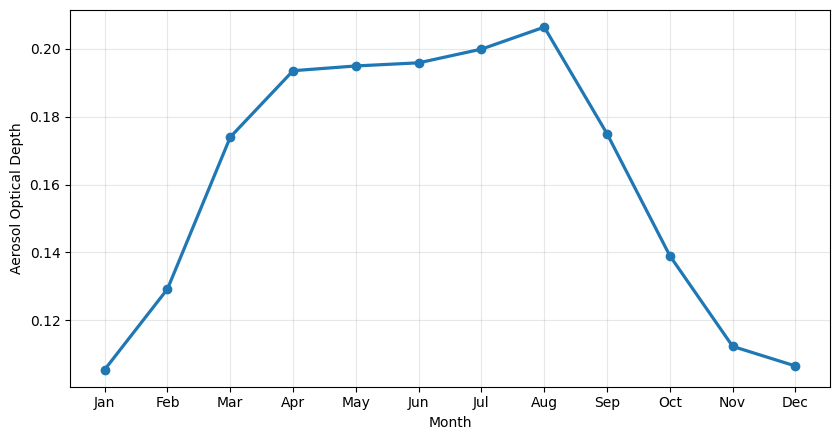

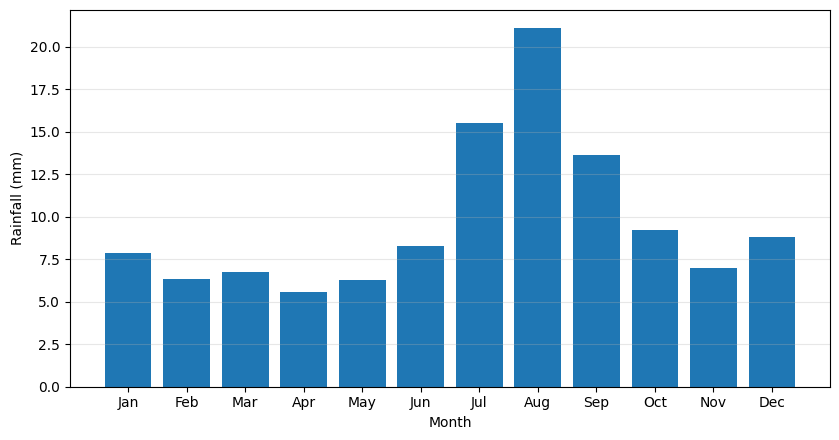

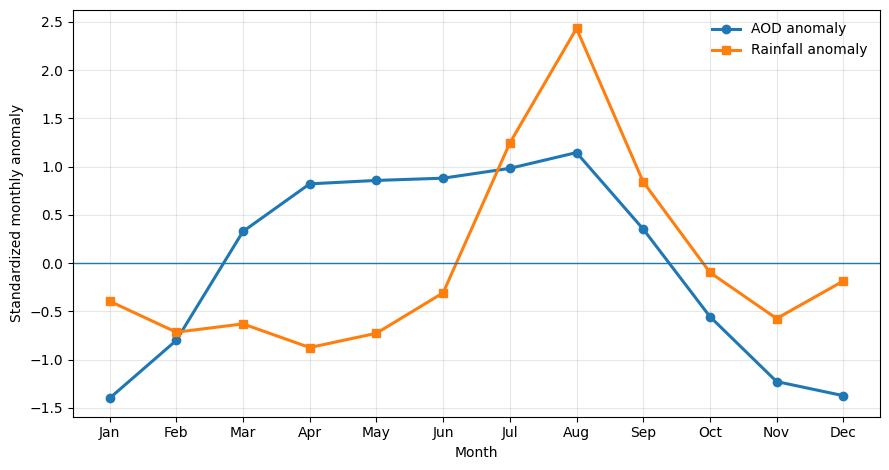

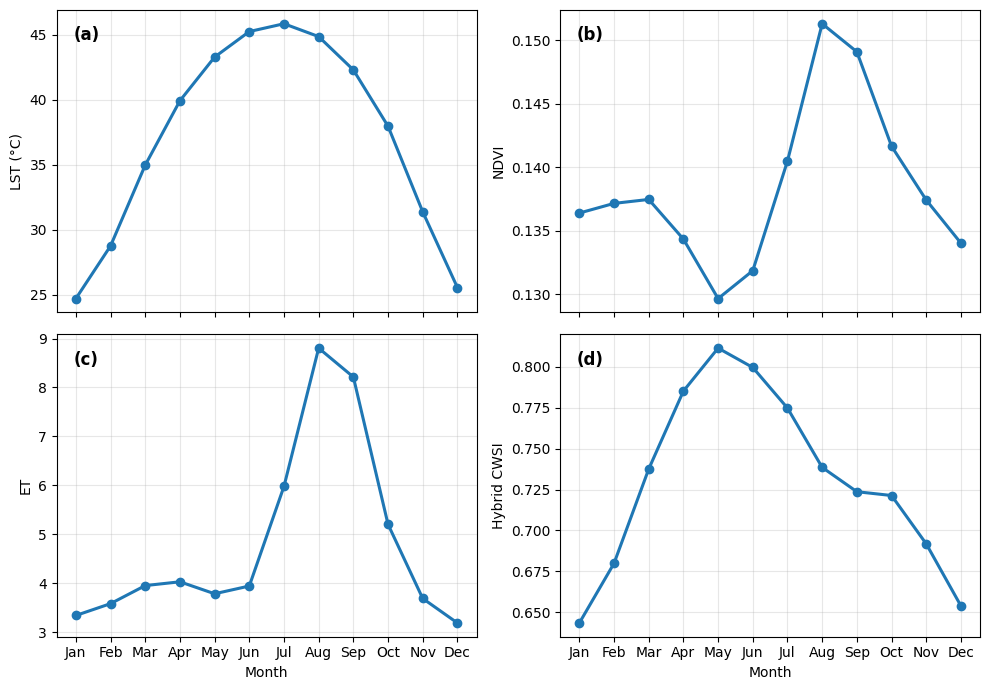

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
csv_name = list(uploaded.keys())[0]

df = pd.read_csv(csv_name)
df = df[['year','month','AOD','Rainfall','LST','NDVI','ET','CWSI']].dropna()
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

clim = df.groupby('month').agg({
    'AOD':'mean',
    'Rainfall':'mean',
    'LST':'mean',
    'NDVI':'mean',
    'ET':'mean',
    'CWSI':'mean'
}).reset_index()

# Standardize for combined monthly stress figure
for col in ['AOD','Rainfall','LST','NDVI','ET','CWSI']:
    clim[col+'_z'] = (clim[col] - clim[col].mean()) / clim[col].std()

# ============================================================
# FIGURE 2 — Monthly AOD climatology
# ============================================================

plt.figure(figsize=(8.5,4.5))
plt.plot(clim['month'], clim['AOD'], marker='o', linewidth=2.3)
plt.xticks(range(1,13), month_names)
plt.xlabel('Month')
plt.ylabel('Aerosol Optical Depth')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figure_2_Monthly_AOD_Climatology.png', dpi=700, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 3 — Monthly rainfall climatology
# ============================================================

plt.figure(figsize=(8.5,4.5))
plt.bar(clim['month'], clim['Rainfall'])
plt.xticks(range(1,13), month_names)
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Figure_3_Monthly_Rainfall_Climatology.png', dpi=700, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 4 — Monthly dust-rainfall contrast
# ============================================================

fig, ax1 = plt.subplots(figsize=(9,4.8))

ax1.plot(clim['month'], clim['AOD_z'], marker='o', linewidth=2.2, label='AOD anomaly')
ax1.plot(clim['month'], clim['Rainfall_z'], marker='s', linewidth=2.2, label='Rainfall anomaly')
ax1.axhline(0, linewidth=1)

ax1.set_xticks(range(1,13))
ax1.set_xticklabels(month_names)
ax1.set_xlabel('Month')
ax1.set_ylabel('Standardized monthly anomaly')
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=False)

plt.tight_layout()
plt.savefig('Figure_4_Monthly_AOD_Rainfall_Contrast.png', dpi=700, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 6 — Monthly environmental stress panel
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10,7), sharex=True)
axes = axes.flatten()

plots = [
    ('LST', 'LST (°C)', '(a)'),
    ('NDVI', 'NDVI', '(b)'),
    ('ET', 'ET', '(c)'),
    ('CWSI', 'Hybrid CWSI', '(d)')
]

for ax, (var, ylabel, label) in zip(axes, plots):
    ax.plot(clim['month'], clim[var], marker='o', linewidth=2.2)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_names)
    ax.grid(True, alpha=0.3)
    ax.text(0.04, 0.90, label, transform=ax.transAxes,
            fontsize=12, fontweight='bold')

axes[2].set_xlabel('Month')
axes[3].set_xlabel('Month')

plt.tight_layout()
plt.savefig('Figure_6_Monthly_Environmental_Stress_Panel.png', dpi=700, bbox_inches='tight')
plt.show()

clim.to_csv('Monthly_Climatology_Summary_2001_2024.csv', index=False)
files.download('Figure_2_Monthly_AOD_Climatology.png')
files.download('Figure_3_Monthly_Rainfall_Climatology.png')
files.download('Figure_4_Monthly_AOD_Rainfall_Contrast.png')
files.download('Figure_6_Monthly_Environmental_Stress_Panel.png')
files.download('Monthly_Climatology_Summary_2001_2024.csv')

Saving NorthAfrica_Monthly_Climate_Stress_2001_2024.csv to NorthAfrica_Monthly_Climate_Stress_2001_2024 (1).csv


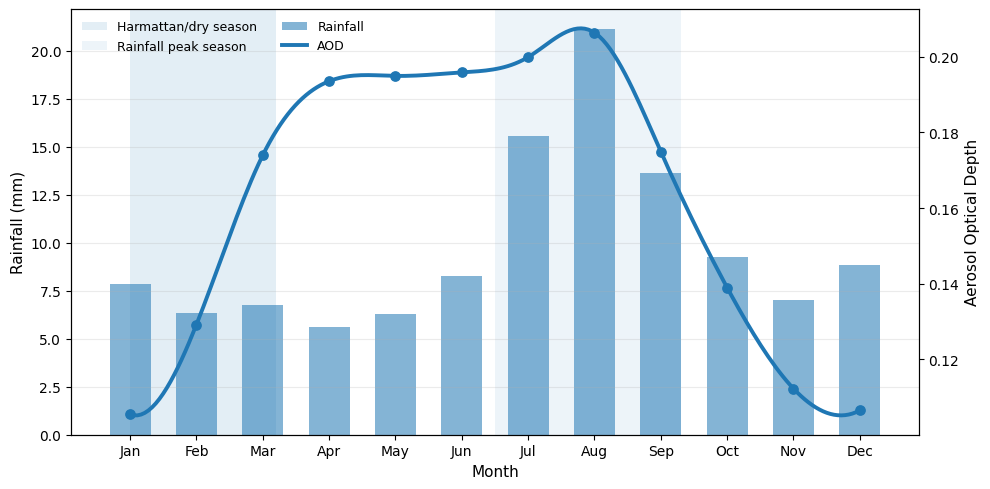

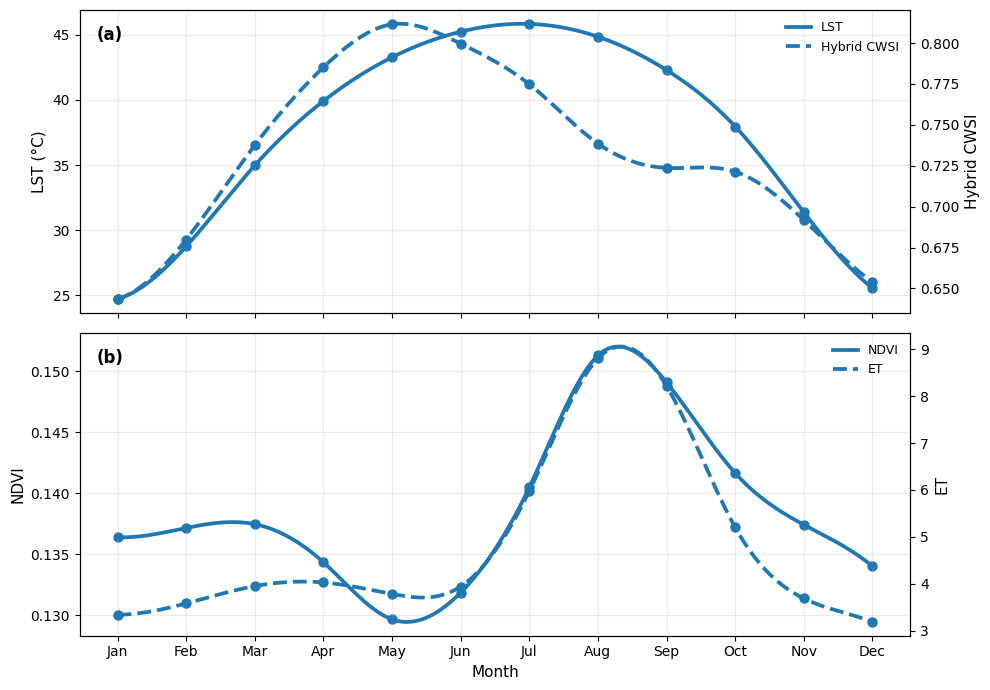

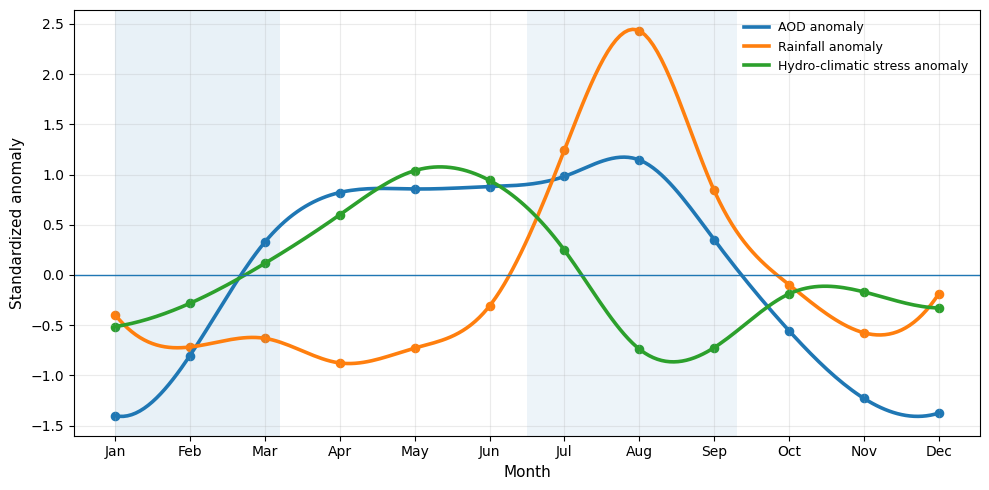

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ============================================================
# FINAL Q1-STYLE MONTHLY CLIMATOLOGY FIGURES
# North Africa, 2001–2024
# Input: NorthAfrica_Monthly_Climate_Stress_2001_2024.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from google.colab import files

# -------------------- 1. UPLOAD CSV --------------------
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]

df = pd.read_csv(csv_name)

df = df[['year', 'month', 'AOD', 'Rainfall', 'LST', 'NDVI', 'ET', 'CWSI']].dropna()

df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)

for col in ['AOD', 'Rainfall', 'LST', 'NDVI', 'ET', 'CWSI']:
    df[col] = df[col].astype(float)

# -------------------- 2. MONTHLY CLIMATOLOGY --------------------
clim = df.groupby('month').agg(
    AOD_mean=('AOD', 'mean'),
    AOD_std=('AOD', 'std'),
    Rainfall_mean=('Rainfall', 'mean'),
    Rainfall_std=('Rainfall', 'std'),
    LST_mean=('LST', 'mean'),
    LST_std=('LST', 'std'),
    NDVI_mean=('NDVI', 'mean'),
    NDVI_std=('NDVI', 'std'),
    ET_mean=('ET', 'mean'),
    ET_std=('ET', 'std'),
    CWSI_mean=('CWSI', 'mean'),
    CWSI_std=('CWSI', 'std')
).reset_index()

months = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# -------------------- 3. SMOOTHING FUNCTION --------------------
def smooth_curve(x, y, points=200):
    x_new = np.linspace(x.min(), x.max(), points)
    spline = make_interp_spline(x, y, k=3)
    y_new = spline(x_new)
    return x_new, y_new

# Standardized values for anomaly-style figure
for var in ['AOD_mean', 'Rainfall_mean', 'LST_mean', 'NDVI_mean', 'ET_mean', 'CWSI_mean']:
    clim[var + '_z'] = (clim[var] - clim[var].mean()) / clim[var].std()

# Stress anomaly: high LST + high CWSI + low NDVI + low ET
clim['Hydroclimatic_Stress_z'] = (
    clim['LST_mean_z'] +
    clim['CWSI_mean_z'] -
    clim['NDVI_mean_z'] -
    clim['ET_mean_z']
) / 4

# ============================================================
# FIGURE 2 — DUST–RAINFALL SEASONAL COUPLING
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 5))

# Seasonal shading
ax1.axvspan(1, 3.2, alpha=0.12, label='Harmattan/dry season')
ax1.axvspan(6.5, 9.3, alpha=0.08, label='Rainfall peak season')

# Rainfall bars
ax1.bar(
    clim['month'],
    clim['Rainfall_mean'],
    width=0.62,
    alpha=0.55,
    label='Rainfall'
)

ax1.set_ylabel('Rainfall (mm)', fontsize=11)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_xticks(months)
ax1.set_xticklabels(month_labels)
ax1.grid(True, axis='y', alpha=0.25)

# AOD line
ax2 = ax1.twinx()

x_s, y_s = smooth_curve(months, clim['AOD_mean'].values)

ax2.plot(
    x_s,
    y_s,
    linewidth=2.8,
    label='AOD'
)

ax2.scatter(
    clim['month'],
    clim['AOD_mean'],
    s=45,
    zorder=5
)

ax2.set_ylabel('Aerosol Optical Depth', fontsize=11)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    fontsize=9,
    loc='upper left',
    ncol=2
)

plt.tight_layout()
plt.savefig(
    'Figure_2_Q1_Monthly_Dust_Rainfall_Coupling.png',
    dpi=700,
    bbox_inches='tight'
)
plt.show()


# ============================================================
# FIGURE 3 — ENVIRONMENTAL RESPONSE SEASONAL DYNAMICS
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Panel a: LST and CWSI
x1, lst_s = smooth_curve(months, clim['LST_mean'].values)
x2, cwsi_s = smooth_curve(months, clim['CWSI_mean'].values)

ax = axes[0]
ax.plot(x1, lst_s, linewidth=2.7, label='LST')
ax.scatter(months, clim['LST_mean'], s=42)

ax.set_ylabel('LST (°C)', fontsize=11)
ax.grid(True, alpha=0.25)

ax_r = ax.twinx()
ax_r.plot(x2, cwsi_s, linewidth=2.7, linestyle='--', label='Hybrid CWSI')
ax_r.scatter(months, clim['CWSI_mean'], s=42)
ax_r.set_ylabel('Hybrid CWSI', fontsize=11)

ax.text(
    0.02, 0.90, '(a)',
    transform=ax.transAxes,
    fontsize=12,
    fontweight='bold'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    fontsize=9,
    loc='upper right'
)

# Panel b: NDVI and ET
x3, ndvi_s = smooth_curve(months, clim['NDVI_mean'].values)
x4, et_s = smooth_curve(months, clim['ET_mean'].values)

ax = axes[1]
ax.plot(x3, ndvi_s, linewidth=2.7, label='NDVI')
ax.scatter(months, clim['NDVI_mean'], s=42)
ax.set_ylabel('NDVI', fontsize=11)
ax.grid(True, alpha=0.25)

ax_r = ax.twinx()
ax_r.plot(x4, et_s, linewidth=2.7, linestyle='--', label='ET')
ax_r.scatter(months, clim['ET_mean'], s=42)
ax_r.set_ylabel('ET', fontsize=11)

ax.text(
    0.02, 0.90, '(b)',
    transform=ax.transAxes,
    fontsize=12,
    fontweight='bold'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    fontsize=9,
    loc='upper right'
)

axes[1].set_xticks(months)
axes[1].set_xticklabels(month_labels)
axes[1].set_xlabel('Month', fontsize=11)

plt.tight_layout()
plt.savefig(
    'Figure_3_Q1_Monthly_Environmental_Response.png',
    dpi=700,
    bbox_inches='tight'
)
plt.show()


# ============================================================
# FIGURE 4 — STANDARDIZED MONTHLY HYDROCLIMATIC ANOMALY PHASES
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

variables = {
    'AOD_mean_z': 'AOD anomaly',
    'Rainfall_mean_z': 'Rainfall anomaly',
    'Hydroclimatic_Stress_z': 'Hydro-climatic stress anomaly'
}

for var, label in variables.items():
    x_s, y_s = smooth_curve(months, clim[var].values)
    ax.plot(x_s, y_s, linewidth=2.6, label=label)
    ax.scatter(months, clim[var], s=35)

ax.axhline(0, linewidth=1)
ax.axvspan(1, 3.2, alpha=0.10)
ax.axvspan(6.5, 9.3, alpha=0.08)

ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Standardized anomaly', fontsize=11)
ax.grid(True, alpha=0.25)

ax.legend(frameon=False, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(
    'Figure_4_Q1_Monthly_Hydroclimatic_Anomaly_Phases.png',
    dpi=700,
    bbox_inches='tight'
)
plt.show()


# -------------------- 4. SAVE SUMMARY TABLE --------------------
clim.to_csv('Monthly_Climatology_Summary_Q1_Style.csv', index=False)

files.download('Figure_2_Q1_Monthly_Dust_Rainfall_Coupling.png')
files.download('Figure_3_Q1_Monthly_Environmental_Response.png')
files.download('Figure_4_Q1_Monthly_Hydroclimatic_Anomaly_Phases.png')
files.download('Monthly_Climatology_Summary_Q1_Style.csv')